# Setup
Dependency installs, Drive mounting, and quick environment checks before the main workflow.


In [ ]:
!pip install -q timm scikit-learn matplotlib tqdm pandas pillow

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# ============================================================
# EVA02 H100 OPTUNA LOCAL-FIRST CHECKPOINTS
# Saves all checkpoints locally, copies only top 4 trials to Drive
# ============================================================

!pip -q install timm optuna scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 19.9 MB/s eta 0:00:00


In [ ]:
import torch
print(torch.__version__)

2.11.0+cu128


# Trial Run
Optuna trial search / two-stage run. Run this first to identify the best trial settings.


In [ ]:
# ============================================================
# EVA02 H100 OPTUNA TWO-STAGE RUN
# Stage 1: 40 Optuna trials using ONE stratified holdout split only
# Stage 2: take top 4 trial params and run full 4-fold CV only for those
# RAM-safe defaults: batch 32 x accumulation 2 | no random erasing | no label smoothing
# Saves ALL tuning checkpoints locally first; copies only top-4 full-CV checkpoints to Drive
# Final ensemble over top 4 trials x 4 folds
#
# Input:
#   /content/drive/MyDrive/Kaggle/train
#   /content/drive/MyDrive/Kaggle/test
#
# Output directory:
#   /content/drive/MyDrive/Kaggle/eva02_h100_100trials_best4
#
# Main outputs:
#   eva02_h100_best4trials_ID_target.csv
#   eva02_h100_best4trials_probs.npy
#   optuna_trials.csv
#   study_best_trials.json
# ============================================================

# In Colab, run once before this script/cell if needed:
# !pip -q install timm optuna scikit-learn

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import gc
import json
import math
import time
import random
import shutil
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

import timm
import optuna
from optuna.samplers import TPESampler
from timm.data import Mixup
from timm.loss import SoftTargetCrossEntropy

from torchvision import transforms
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass

# ============================================================
# PATHS
# ============================================================

TRAIN_DIR = "/content/drive/MyDrive/Kaggle/train"
TEST_DIR  = "/content/drive/MyDrive/Kaggle/test"

# Drive output directory: only small metadata + final outputs + copied top 4 trial checkpoints go here.
SAVE_DIR = "/content/drive/MyDrive/Kaggle/eva02_h100_40trials_tune1fold_top4_4fold"
DRIVE_TRIALS_DIR = os.path.join(SAVE_DIR, "top4_fullcv_checkpoints")

# Fast local directory: ALL trial checkpoints are saved here first.
# In Colab/Kaggle this is much faster than writing every .pt directly to Drive.
LOCAL_WORK_DIR = "/content/eva02_h100_40trials_tune1fold_top4_4fold"
LOCAL_TRIALS_DIR = os.path.join(LOCAL_WORK_DIR, "all_trial_checkpoints")

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(DRIVE_TRIALS_DIR, exist_ok=True)
os.makedirs(LOCAL_WORK_DIR, exist_ok=True)
os.makedirs(LOCAL_TRIALS_DIR, exist_ok=True)

FINAL_CSV_PATH = os.path.join(SAVE_DIR, "eva02_h100_best4trials_ID_target.csv")
FINAL_PROBS_PATH = os.path.join(SAVE_DIR, "eva02_h100_best4trials_probs.npy")
INFO_PATH = os.path.join(SAVE_DIR, "study_best_trials.json")
TRIALS_CSV_PATH = os.path.join(SAVE_DIR, "optuna_trials.csv")
BEST4_CKPT_CSV_PATH = os.path.join(SAVE_DIR, "best4_trial_fold_checkpoints.csv")

# Keep the Optuna DB on Drive so you can resume after disconnects.
# Checkpoints stay local until a trial enters the current top 4.
STUDY_DB_PATH = os.path.join(SAVE_DIR, "eva02_h100_optuna_study.db")

print("Drive save dir:", SAVE_DIR)
print("Local checkpoint dir:", LOCAL_TRIALS_DIR)
print("Drive top-4 checkpoint dir:", DRIVE_TRIALS_DIR)
print("Two-stage mode: all trials use 1 holdout split; only top 4 use 4-fold CV")
print("RAM-safe DataLoader: NUM_WORKERS=0, PIN_MEMORY=False, PRED_BATCH=8")

# ============================================================
# CONFIG
# ============================================================

SEED = 42
NUM_CLASSES = 100
N_FOLDS = 4
N_TRIALS = 30
TUNE_VAL_FRACTION = 1.0 / N_FOLDS
SAVE_TOP_K_TRIALS = 1
FINAL_EPOCHS = 150
PATIENCE = 15

BATCH_SIZE = 42
ACCUM_STEPS = 1
PRED_BATCH = 42
NUM_WORKERS = 4
PIN_MEMORY = False
PERSISTENT_WORKERS = False
PREFETCH_FACTOR = 1

USE_MIXUP = True
USE_AMP = True
USE_TTA_FLIP = True

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)
print("Train dir exists:", os.path.exists(TRAIN_DIR))
print("Test dir exists:", os.path.exists(TEST_DIR))

if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM GB:", torch.cuda.get_device_properties(0).total_memory / 1024**3)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True

# ============================================================
# SEED
# ============================================================

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

# ============================================================
# DATA
# ============================================================

def get_train_items(train_dir):
    items = []
    for label in sorted(os.listdir(train_dir), key=lambda x: int(x) if x.isdigit() else x):
        class_dir = os.path.join(train_dir, label)
        if not os.path.isdir(class_dir):
            continue
        for fname in os.listdir(class_dir):
            if fname.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
                items.append((os.path.join(class_dir, fname), int(label)))
    return items


def get_test_items(test_dir):
    files = []
    for fname in os.listdir(test_dir):
        if fname.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
            files.append(fname)
    files = sorted(
        files,
        key=lambda x: int(os.path.splitext(x)[0]) if os.path.splitext(x)[0].isdigit() else x
    )
    return [(os.path.join(test_dir, f), f) for f in files]

train_items = get_train_items(TRAIN_DIR)
test_items = get_test_items(TEST_DIR)
labels = np.array([y for _, y in train_items])

print("Train images:", len(train_items))
print("Test images:", len(test_items))
print("Classes:", len(set(labels)))
print("Smallest class:", pd.Series(labels).value_counts().min())
print("Largest class:", pd.Series(labels).value_counts().max())

assert len(train_items) > 0, "No train images found."
assert len(test_items) > 0, "No test images found."
assert len(set(labels)) == NUM_CLASSES, "Expected 100 classes."

# ============================================================
# DATASET
# ============================================================

class ImageDataset(Dataset):
    def __init__(self, items, transform=None):
        self.items = items
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, label_or_id = self.items[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label_or_id

# ============================================================
# TRANSFORMS
# ============================================================

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)


def make_transforms(img_size, crop_min, rot_deg, color_strength):
    train_tfms = transforms.Compose([
        transforms.RandomResizedCrop(img_size, scale=(crop_min, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(rot_deg),
        transforms.ColorJitter(
            brightness=color_strength,
            contrast=color_strength,
            saturation=color_strength,
            hue=0.03,
        ),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    val_tfms = transforms.Compose([
        transforms.Resize(int(img_size * 1.10)),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    return train_tfms, val_tfms, val_tfms

# ============================================================
# MODEL NAME
# ============================================================


def resolve_model_name(patterns):
    all_models = set(timm.list_models(pretrained=True))
    for p in patterns:
        matches = sorted([m for m in all_models if p in m])
        if matches:
            print("Resolved", p, "->", matches[0])
            return matches[0]
    raise ValueError(f"No timm model found for patterns: {patterns}")

MODEL_NAME = resolve_model_name([
    "eva02_large_patch14_448.mim_m38m_ft_in22k_ft_in1k",
    "eva02_large_patch14_448",
    "eva02_large",
])

# ============================================================
# STARTING PARAMETERS FROM YOUR EVA02 SCRIPT
# ============================================================

START_PARAMS = {
    "img_size": 448,
    "batch_size": BATCH_SIZE,
    "accum_steps": ACCUM_STEPS,
    "lr": 7e-5,
    "weight_decay": 0.075,
    "drop_rate": 0.166,
    "drop_path_rate": 0.175,
    "mixup_alpha": 0.02,
    "cutmix_alpha": 0.3,
    "mixup_prob": 0.35,
    "label_smoothing": 0.0,
    "rand_erasing": 0.0,
    "rot_deg": 6,
    "color_strength": 0.17,
    "crop_min": 0.62,
    "warmup_epochs": 4,
}

# ============================================================
# OPTUNA PARAMETER SEARCH SPACE
# Centered around your starting EVA02 parameters.
# First trial is forced to START_PARAMS using enqueue_trial below.
# ============================================================


def suggest_params(trial):
    return {
        "img_size": 448,
        "batch_size": BATCH_SIZE,
        "accum_steps": ACCUM_STEPS,
        "lr": trial.suggest_float("lr", 4.0e-5, 1.6e-4, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 0.045, 0.11),
        "drop_rate": trial.suggest_float("drop_rate", 0.08, 0.24),
        "drop_path_rate": trial.suggest_float("drop_path_rate", 0.10, 0.26),
        "mixup_alpha": trial.suggest_float("mixup_alpha", 0.0, 0.12),
        "cutmix_alpha": trial.suggest_float("cutmix_alpha", 0.25, 0.85),
        "mixup_prob": trial.suggest_float("mixup_prob", 0.35, 0.75),
        "label_smoothing": 0.0,
        "rand_erasing": 0.0,
        "rot_deg": trial.suggest_int("rot_deg", 3, 9),
        "color_strength": trial.suggest_float("color_strength", 0.10, 0.26),
        "crop_min": trial.suggest_float("crop_min", 0.55, 0.70),
        "warmup_epochs": trial.suggest_int("warmup_epochs", 3, 7),
    }

# ============================================================
# TRAINING HELPERS
# ============================================================


def make_model(p):
    model = timm.create_model(
        MODEL_NAME,
        pretrained=True,
        num_classes=NUM_CLASSES,
        drop_rate=p["drop_rate"],
        drop_path_rate=p["drop_path_rate"],
    )
    return model


def make_scheduler(optimizer, total_steps, warmup_steps):
    def lr_lambda(step):
        if step < warmup_steps:
            return float(step + 1) / float(max(1, warmup_steps))
        progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def cleanup():
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()


def train_one_epoch(model, loader, optimizer, scheduler, scaler, criterion, mixup_fn, accum_steps):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_n = 0
    optimizer.zero_grad(set_to_none=True)

    for step, (x, y) in enumerate(loader):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        y_for_acc = y.clone()

        if mixup_fn is not None:
            x, y_mixed = mixup_fn(x, y)
        else:
            y_mixed = y

        with autocast(device_type="cuda", enabled=(USE_AMP and DEVICE == "cuda")):
            logits = model(x)
            loss = criterion(logits, y_mixed) / accum_steps

        scaler.scale(loss).backward()

        if (step + 1) % accum_steps == 0 or (step + 1) == len(loader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()

        bs = x.size(0)
        total_loss += loss.item() * accum_steps * bs
        total_correct += (logits.detach().argmax(dim=1) == y_for_acc).sum().item()
        total_n += bs

    return total_loss / total_n, total_correct / total_n


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_n = 0

    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        with autocast(device_type="cuda", enabled=(USE_AMP and DEVICE == "cuda")):
            logits = model(x)
            loss = criterion(logits, y)

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_n += bs

    return total_loss / total_n, total_correct / total_n

# ============================================================
# SINGLE FOLD TRAIN
# ============================================================


def train_one_fold(trial_number, fold, train_idx, val_idx, p, trial_dir):
    print("\n" + "-" * 90)
    print(f"TRIAL {trial_number} | FOLD {fold}/{N_FOLDS}")
    print("-" * 90)

    seed_everything(SEED + trial_number * 100 + fold)

    train_tfms, val_tfms, _ = make_transforms(
        img_size=p["img_size"],
        crop_min=p["crop_min"],
        rot_deg=p["rot_deg"],
        color_strength=p["color_strength"],
    )

    tr_items = [train_items[i] for i in train_idx]
    va_items = [train_items[i] for i in val_idx]

    tr_ds = ImageDataset(tr_items, transform=train_tfms)
    va_ds = ImageDataset(va_items, transform=val_tfms)

    tr_loader = DataLoader(
        tr_ds,
        batch_size=p["batch_size"],
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=True,
        persistent_workers=(PERSISTENT_WORKERS and NUM_WORKERS > 0),
        prefetch_factor=(PREFETCH_FACTOR if NUM_WORKERS > 0 else None),
    )

    va_loader = DataLoader(
        va_ds,
        batch_size=PRED_BATCH,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=(PERSISTENT_WORKERS and NUM_WORKERS > 0),
        prefetch_factor=(PREFETCH_FACTOR if NUM_WORKERS > 0 else None),
    )

    model = make_model(p).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=p["lr"], weight_decay=p["weight_decay"])

    total_update_steps = math.ceil(len(tr_loader) / p["accum_steps"]) * FINAL_EPOCHS
    warmup_steps = math.ceil(len(tr_loader) / p["accum_steps"]) * p["warmup_epochs"]
    scheduler = make_scheduler(optimizer, total_update_steps, warmup_steps)
    scaler = GradScaler(enabled=(USE_AMP and DEVICE == "cuda"))

    if USE_MIXUP:
        mixup_fn = Mixup(
            mixup_alpha=p["mixup_alpha"],
            cutmix_alpha=p["cutmix_alpha"],
            prob=p["mixup_prob"],
            switch_prob=0.5,
            mode="batch",
            label_smoothing=0.0,
            num_classes=NUM_CLASSES,
        )
        train_criterion = SoftTargetCrossEntropy()
    else:
        mixup_fn = None
        train_criterion = nn.CrossEntropyLoss()

    val_criterion = nn.CrossEntropyLoss()

    best_acc = -1.0
    best_loss = 999.0
    best_epoch = -1
    bad_epochs = 0

    ckpt_path = os.path.join(trial_dir, f"eva02_trial{trial_number:03d}_fold{fold}_best.pt")

    for epoch in range(1, FINAL_EPOCHS + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(
            model=model,
            loader=tr_loader,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            criterion=train_criterion,
            mixup_fn=mixup_fn,
            accum_steps=p["accum_steps"],
        )

        val_loss, val_acc = evaluate(model, va_loader, val_criterion)
        improved = val_acc > best_acc

        if improved:
            best_acc = val_acc
            best_loss = val_loss
            best_epoch = epoch
            bad_epochs = 0
            torch.save(
                {
                    "family": "eva02",
                    "model_name": MODEL_NAME,
                    "trial_number": trial_number,
                    "fold": fold,
                    "epoch": epoch,
                    "best_acc": best_acc,
                    "best_loss": best_loss,
                    "params": p,
                    "model_state_dict": model.state_dict(),
                },
                ckpt_path,
            )
            print("Saved new best:", ckpt_path)
        else:
            bad_epochs += 1

        dt = time.time() - t0
        gap = train_acc - val_acc
        print(
            f"Trial {trial_number} | Fold {fold} | Epoch {epoch}/{FINAL_EPOCHS} | "
            f"Train Loss {train_loss:.4f} | Train Acc {train_acc:.4f} | "
            f"Val Loss {val_loss:.4f} | Val Acc {val_acc:.4f} | "
            f"Gap {gap:.4f} | Best {best_acc:.4f} @ {best_epoch} | "
            f"Bad {bad_epochs}/{PATIENCE} | {dt:.1f}s"
        )

        if DEVICE == "cuda":
            print(
                "VRAM allocated:", round(torch.cuda.memory_allocated() / 1024**3, 2),
                "GB | reserved:", round(torch.cuda.memory_reserved() / 1024**3, 2),
                "GB | peak:", round(torch.cuda.max_memory_allocated() / 1024**3, 2), "GB"
            )

        if bad_epochs >= PATIENCE:
            print("Early stopping fold.")
            break

    fold_result = {
        "fold": fold,
        "best_acc": float(best_acc),
        "best_loss": float(best_loss),
        "best_epoch": int(best_epoch),
        "ckpt": ckpt_path,
    }

    del model, optimizer, scheduler, scaler, tr_loader, va_loader, tr_ds, va_ds
    cleanup()
    return fold_result

# ============================================================
# TOP-K CHECKPOINT COPYING
# ALL checkpoints stay locally in LOCAL_TRIALS_DIR.
# Only the current best 4 completed trial folders are copied to Drive.
# ============================================================


def get_completed_trials_sorted(study):
    completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE and t.value is not None]
    completed = sorted(completed, key=lambda t: t.value, reverse=True)
    return completed


def sync_top_k_trial_dirs_to_drive(study, top_k=SAVE_TOP_K_TRIALS):
    """Copy current top-k completed trial folders from local disk to Drive.

    This does NOT delete local checkpoints. It only deletes stale non-top-k folders
    from the Drive top4 directory so Drive contains only the current best 4 trials.
    """
    best = get_completed_trials_sorted(study)[:top_k]
    keep_names = {f"trial_{t.number:03d}" for t in best}

    # Remove old Drive top-4 folders that are no longer top 4.
    for name in os.listdir(DRIVE_TRIALS_DIR):
        dst = os.path.join(DRIVE_TRIALS_DIR, name)
        if os.path.isdir(dst) and name.startswith("trial_") and name not in keep_names:
            shutil.rmtree(dst, ignore_errors=True)

    # Copy/sync current top 4 from local to Drive.
    for t in best:
        name = f"trial_{t.number:03d}"
        src = os.path.join(LOCAL_TRIALS_DIR, name)
        dst = os.path.join(DRIVE_TRIALS_DIR, name)
        if not os.path.isdir(src):
            print("Warning: local top trial folder missing, cannot copy:", src)
            continue
        shutil.copytree(src, dst, dirs_exist_ok=True)
        print("Copied top trial to Drive:", dst)


def local_trial_dir(trial_number):
    return os.path.join(LOCAL_TRIALS_DIR, f"trial_{trial_number:03d}")


def drive_trial_dir(trial_number):
    return os.path.join(DRIVE_TRIALS_DIR, f"trial_{trial_number:03d}")


def save_study_tables(study):
    df = study.trials_dataframe()
    df.to_csv(TRIALS_CSV_PATH, index=False)

    best_trials = []
    for rank, t in enumerate(get_completed_trials_sorted(study)[:SAVE_TOP_K_TRIALS], start=1):
        best_trials.append({
            "rank": rank,
            "trial_number": t.number,
            "mean_cv_acc": float(t.value),
            "user_attrs": t.user_attrs,
            "params": t.params,
            "local_trial_dir": local_trial_dir(t.number),
            "drive_trial_dir": drive_trial_dir(t.number),
        })

    with open(INFO_PATH, "w") as f:
        json.dump({
            "model_name": MODEL_NAME,
            "n_trials": N_TRIALS,
            "n_folds": N_FOLDS,
            "final_epochs": FINAL_EPOCHS,
            "patience": PATIENCE,
            "batch_size": BATCH_SIZE,
            "saved_top_k_trials": SAVE_TOP_K_TRIALS,
            "best_trials": best_trials,
        }, f, indent=2)


def trial_callback(study, trial):
    save_study_tables(study)
    sync_top_k_trial_dirs_to_drive(study, SAVE_TOP_K_TRIALS)
    print("\nCurrent top trials:")
    for rank, t in enumerate(get_completed_trials_sorted(study)[:SAVE_TOP_K_TRIALS], start=1):
        print(f"Rank {rank}: Trial {t.number} | Mean CV Acc {t.value:.5f}")

# ============================================================
# OBJECTIVE: 4-FOLD CV PER TRIAL
# ============================================================


def objective(trial):
    p = suggest_params(trial)
    trial_number = trial.number
    # Save every trial checkpoint locally first.
    trial_dir = local_trial_dir(trial_number)
    os.makedirs(trial_dir, exist_ok=True)

    print("\n" + "=" * 90)
    print(f"START TRIAL {trial_number}/{N_TRIALS - 1}")
    print(json.dumps(p, indent=2))
    print("=" * 90)

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels)), labels), start=1):
        fold_result = train_one_fold(trial_number, fold, train_idx, val_idx, p, trial_dir)
        fold_results.append(fold_result)

        current_mean = float(np.mean([x["best_acc"] for x in fold_results]))
        trial.report(current_mean, step=fold)

        # Conservative pruning only after at least 2 folds.
        if fold >= 2 and trial.should_prune():
            print(f"Pruned trial {trial_number} after fold {fold}; current mean={current_mean:.5f}")
            raise optuna.exceptions.TrialPruned()

    mean_acc = float(np.mean([x["best_acc"] for x in fold_results]))
    std_acc = float(np.std([x["best_acc"] for x in fold_results]))
    mean_loss = float(np.mean([x["best_loss"] for x in fold_results]))

    trial.set_user_attr("mean_cv_acc", mean_acc)
    trial.set_user_attr("std_cv_acc", std_acc)
    trial.set_user_attr("mean_cv_loss", mean_loss)
    trial.set_user_attr("fold_results", fold_results)
    trial.set_user_attr("trial_dir", trial_dir)
    trial.set_user_attr("full_params", p)

    with open(os.path.join(trial_dir, "trial_result.json"), "w") as f:
        json.dump({
            "trial_number": trial_number,
            "mean_cv_acc": mean_acc,
            "std_cv_acc": std_acc,
            "mean_cv_loss": mean_loss,
            "params": p,
            "fold_results": fold_results,
        }, f, indent=2)

    print("\n" + "=" * 90)
    print(f"FINISHED TRIAL {trial_number} | Mean CV Acc {mean_acc:.5f} | Std {std_acc:.5f}")
    print("=" * 90)
    return mean_acc

# ============================================================
# PREDICT HELPERS
# ============================================================

@torch.no_grad()
def predict_checkpoint(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    p = ckpt["params"]
    _, _, test_tfms = make_transforms(
        img_size=p["img_size"],
        crop_min=p["crop_min"],
        rot_deg=p["rot_deg"],
        color_strength=p["color_strength"],
    )

    test_ds = ImageDataset(test_items, transform=test_tfms)
    test_loader = DataLoader(
        test_ds,
        batch_size=PRED_BATCH,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=(PERSISTENT_WORKERS and NUM_WORKERS > 0),
        prefetch_factor=(PREFETCH_FACTOR if NUM_WORKERS > 0 else None),
    )

    model = make_model(p).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    all_probs = []
    all_ids = []

    for x, ids in test_loader:
        x = x.to(DEVICE, non_blocking=True)
        with autocast(device_type="cuda", enabled=(USE_AMP and DEVICE == "cuda")):
            logits = model(x)
            if USE_TTA_FLIP:
                logits_flip = model(torch.flip(x, dims=[3]))
                logits = (logits + logits_flip) / 2.0

        probs = torch.softmax(logits, dim=1).detach().cpu().numpy()
        all_probs.append(probs)
        all_ids.extend(list(ids))

    probs = np.concatenate(all_probs, axis=0)

    del model, test_loader, test_ds
    cleanup()
    return probs, all_ids


def collect_best_trial_ckpts(study):
    best_trials = get_completed_trials_sorted(study)[:SAVE_TOP_K_TRIALS]
    rows = []
    ckpts = []

    for rank, t in enumerate(best_trials, start=1):
        # Prefer local checkpoint folder for prediction. If the runtime restarted and
        # local files are gone, fall back to the Drive-copied top-4 folder.
        trial_dir = local_trial_dir(t.number)
        if not os.path.isdir(trial_dir):
            trial_dir = drive_trial_dir(t.number)
        result_path = os.path.join(trial_dir, "trial_result.json")
        with open(result_path, "r") as f:
            result = json.load(f)

        for fr in result["fold_results"]:
            ckpt_path = fr["ckpt"]
            if not os.path.exists(ckpt_path):
                raise FileNotFoundError(f"Missing checkpoint: {ckpt_path}")
            ckpts.append(ckpt_path)
            rows.append({
                "rank": rank,
                "trial_number": t.number,
                "mean_cv_acc": float(t.value),
                "fold": fr["fold"],
                "fold_best_acc": fr["best_acc"],
                "fold_best_epoch": fr["best_epoch"],
                "ckpt": ckpt_path,
            })

    pd.DataFrame(rows).to_csv(BEST4_CKPT_CSV_PATH, index=False)
    return ckpts


def predict_best4_ensemble(study):
    ckpts = collect_best_trial_ckpts(study)
    print("\nPredicting ensemble over checkpoints:", len(ckpts))

    final_ids = None
    probs_list = []

    for i, ckpt_path in enumerate(ckpts, start=1):
        print(f"Predicting {i}/{len(ckpts)}:", ckpt_path)
        probs, ids = predict_checkpoint(ckpt_path)
        if final_ids is None:
            final_ids = ids
        else:
            assert final_ids == ids, "Test ID order mismatch."
        probs_list.append(probs)

    ensemble_probs = np.mean(probs_list, axis=0)
    ensemble_probs = np.clip(ensemble_probs, 0, None)
    ensemble_probs = ensemble_probs / ensemble_probs.sum(axis=1, keepdims=True)

    preds = ensemble_probs.argmax(axis=1).astype(int)
    sub = pd.DataFrame({"ID": final_ids, "target": preds})
    sub.to_csv(FINAL_CSV_PATH, index=False)
    np.save(FINAL_PROBS_PATH, ensemble_probs)

    print("\nFinal CSV preview:")
    print(sub.head())
    print("\nClass count preview:")
    print(sub["target"].value_counts().sort_index().head(30))
    print("\nSaved final CSV:", FINAL_CSV_PATH)
    print("Saved final probs:", FINAL_PROBS_PATH)


# ============================================================
# OVERRIDE: TWO-STAGE OBJECTIVE
# Stage 1 = one stratified holdout split per Optuna trial.
# Stage 2 = after Optuna finishes, run 4-fold CV only for the top 4 trials.
# ============================================================


def save_study_tables(study):
    df = study.trials_dataframe()
    df.to_csv(TRIALS_CSV_PATH, index=False)

    best_trials = []
    for rank, t in enumerate(get_completed_trials_sorted(study)[:SAVE_TOP_K_TRIALS], start=1):
        best_trials.append({
            "rank": rank,
            "trial_number": t.number,
            "tune_holdout_acc": float(t.value),
            "user_attrs": t.user_attrs,
            "params": t.params,
            "local_tuning_trial_dir": local_trial_dir(t.number),
        })

    with open(INFO_PATH, "w") as f:
        json.dump({
            "mode": "two_stage_tune1fold_then_top4_4fold",
            "model_name": MODEL_NAME,
            "n_trials": N_TRIALS,
            "tuning_folds_per_trial": 1,
            "top_k_full_cv_trials": SAVE_TOP_K_TRIALS,
            "full_cv_folds_for_top_k": N_FOLDS,
            "final_epochs": FINAL_EPOCHS,
            "patience": PATIENCE,
            "batch_size": BATCH_SIZE,
            "accum_steps": ACCUM_STEPS,
            "effective_batch_size": BATCH_SIZE * ACCUM_STEPS,
            "best_tuning_trials": best_trials,
        }, f, indent=2)


def trial_callback(study, trial):
    save_study_tables(study)
    print("\nCurrent top tuning trials from one holdout split:")
    for rank, t in enumerate(get_completed_trials_sorted(study)[:SAVE_TOP_K_TRIALS], start=1):
        print(f"Rank {rank}: Trial {t.number} | Holdout Acc {t.value:.5f}", flush=True)


def objective(trial):
    """Fast Optuna objective: train only one stratified holdout fold per trial."""
    p = suggest_params(trial)
    trial_number = trial.number
    trial_dir = local_trial_dir(trial_number)
    os.makedirs(trial_dir, exist_ok=True)

    print("\n" + "=" * 90, flush=True)
    print(f"START TUNING TRIAL {trial_number}/{N_TRIALS - 1} | ONE HOLDOUT SPLIT ONLY", flush=True)
    print(json.dumps(p, indent=2), flush=True)
    print("=" * 90, flush=True)

    splitter = StratifiedShuffleSplit(
        n_splits=1,
        test_size=TUNE_VAL_FRACTION,
        random_state=SEED + trial_number,
    )
    train_idx, val_idx = next(splitter.split(np.zeros(len(labels)), labels))

    fold_result = train_one_fold(
        trial_number=trial_number,
        fold=1,
        train_idx=train_idx,
        val_idx=val_idx,
        p=p,
        trial_dir=trial_dir,
    )

    holdout_acc = float(fold_result["best_acc"])
    trial.report(holdout_acc, step=1)

    trial.set_user_attr("mode", "one_holdout_split_tuning")
    trial.set_user_attr("tune_holdout_acc", holdout_acc)
    trial.set_user_attr("tune_holdout_loss", float(fold_result["best_loss"]))
    trial.set_user_attr("tune_fold_result", fold_result)
    trial.set_user_attr("trial_dir", trial_dir)
    trial.set_user_attr("full_params", p)

    with open(os.path.join(trial_dir, "tuning_trial_result.json"), "w") as f:
        json.dump({
            "mode": "one_holdout_split_tuning",
            "trial_number": trial_number,
            "holdout_acc": holdout_acc,
            "params": p,
            "fold_result": fold_result,
        }, f, indent=2)

    print("\n" + "=" * 90, flush=True)
    print(f"FINISHED TUNING TRIAL {trial_number} | Holdout Acc {holdout_acc:.5f}", flush=True)
    print("=" * 90, flush=True)
    return holdout_acc


# ============================================================
# STAGE 2: FULL 4-FOLD CV ONLY FOR TOP 4 TUNING TRIALS
# ============================================================


def top4_fullcv_local_dir(trial_number):
    return os.path.join(LOCAL_WORK_DIR, "top4_fullcv_checkpoints", f"trial_{trial_number:03d}")


def top4_fullcv_drive_dir(trial_number):
    return os.path.join(DRIVE_TRIALS_DIR, f"trial_{trial_number:03d}")


def run_full_cv_for_top_trials(study):
    best_trials = get_completed_trials_sorted(study)[:SAVE_TOP_K_TRIALS]
    assert len(best_trials) > 0, "No completed tuning trials found."

    fullcv_summary = []
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

    for rank, t in enumerate(best_trials, start=1):
        p = dict(t.user_attrs.get("full_params", None) or suggest_params(t))
        trial_number = t.number
        local_dir = top4_fullcv_local_dir(trial_number)
        drive_dir = top4_fullcv_drive_dir(trial_number)
        os.makedirs(local_dir, exist_ok=True)

        print("\n" + "#" * 90, flush=True)
        print(f"FULL 4-FOLD CV FOR TOP-{rank} TUNING TRIAL {trial_number}", flush=True)
        print(f"Original tuning holdout acc: {float(t.value):.5f}", flush=True)
        print(json.dumps(p, indent=2), flush=True)
        print("#" * 90, flush=True)

        fold_results = []
        for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels)), labels), start=1):
            fold_result = train_one_fold(
                trial_number=trial_number,
                fold=fold,
                train_idx=train_idx,
                val_idx=val_idx,
                p=p,
                trial_dir=local_dir,
            )
            fold_results.append(fold_result)

        mean_cv_acc = float(np.mean([fr["best_acc"] for fr in fold_results]))
        std_cv_acc = float(np.std([fr["best_acc"] for fr in fold_results]))
        mean_cv_loss = float(np.mean([fr["best_loss"] for fr in fold_results]))

        result = {
            "rank_from_tuning": rank,
            "trial_number": trial_number,
            "tune_holdout_acc": float(t.value),
            "fullcv_mean_acc": mean_cv_acc,
            "fullcv_std_acc": std_cv_acc,
            "fullcv_mean_loss": mean_cv_loss,
            "params": p,
            "fold_results": fold_results,
            "local_fullcv_dir": local_dir,
            "drive_fullcv_dir": drive_dir,
        }

        with open(os.path.join(local_dir, "fullcv_result.json"), "w") as f:
            json.dump(result, f, indent=2)

        # Copy ONLY these full-CV top-4 trial folders to Drive.
        shutil.copytree(local_dir, drive_dir, dirs_exist_ok=True)
        print("Copied top-4 full-CV checkpoints to Drive:", drive_dir, flush=True)

        fullcv_summary.append(result)

    # Rank top4 again by their real 4-fold CV score, useful for reporting.
    fullcv_summary = sorted(fullcv_summary, key=lambda x: x["fullcv_mean_acc"], reverse=True)
    with open(os.path.join(SAVE_DIR, "top4_fullcv_summary.json"), "w") as f:
        json.dump(fullcv_summary, f, indent=2)

    rows = []
    for full_rank, r in enumerate(fullcv_summary, start=1):
        for fr in r["fold_results"]:
            rows.append({
                "fullcv_rank": full_rank,
                "tuning_rank": r["rank_from_tuning"],
                "trial_number": r["trial_number"],
                "tune_holdout_acc": r["tune_holdout_acc"],
                "fullcv_mean_acc": r["fullcv_mean_acc"],
                "fullcv_std_acc": r["fullcv_std_acc"],
                "fold": fr["fold"],
                "fold_best_acc": fr["best_acc"],
                "fold_best_epoch": fr["best_epoch"],
                "ckpt": fr["ckpt"],
            })
    pd.DataFrame(rows).to_csv(BEST4_CKPT_CSV_PATH, index=False)
    return fullcv_summary


def collect_fullcv_ckpts(fullcv_summary):
    ckpts = []
    for r in fullcv_summary:
        for fr in r["fold_results"]:
            ckpt_path = fr["ckpt"]
            if not os.path.exists(ckpt_path):
                # If local runtime got cleared, use the Drive copy.
                ckpt_path = ckpt_path.replace(r["local_fullcv_dir"], r["drive_fullcv_dir"])
            if not os.path.exists(ckpt_path):
                raise FileNotFoundError(f"Missing checkpoint: {ckpt_path}")
            ckpts.append(ckpt_path)
    return ckpts


def predict_top4_fullcv_ensemble(fullcv_summary):
    ckpts = collect_fullcv_ckpts(fullcv_summary)
    print("\nPredicting final ensemble over top-4 full-CV checkpoints:", len(ckpts), flush=True)

    final_ids = None
    probs_list = []

    for i, ckpt_path in enumerate(ckpts, start=1):
        print(f"Predicting {i}/{len(ckpts)}: {ckpt_path}", flush=True)
        probs, ids = predict_checkpoint(ckpt_path)
        if final_ids is None:
            final_ids = ids
        else:
            assert final_ids == ids, "Test ID order mismatch."
        probs_list.append(probs)

    ensemble_probs = np.mean(probs_list, axis=0)
    ensemble_probs = np.clip(ensemble_probs, 0, None)
    ensemble_probs = ensemble_probs / ensemble_probs.sum(axis=1, keepdims=True)

    preds = ensemble_probs.argmax(axis=1).astype(int)
    sub = pd.DataFrame({"ID": final_ids, "target": preds})
    sub.to_csv(FINAL_CSV_PATH, index=False)
    np.save(FINAL_PROBS_PATH, ensemble_probs)

    print("\nFinal CSV preview:", flush=True)
    print(sub.head(), flush=True)
    print("\nClass count preview:", flush=True)
    print(sub["target"].value_counts().sort_index().head(30), flush=True)
    print("\nSaved final CSV:", FINAL_CSV_PATH, flush=True)
    print("Saved final probs:", FINAL_PROBS_PATH, flush=True)


# ============================================================
# RUN TWO-STAGE STUDY
# ============================================================

sampler = TPESampler(seed=SEED, multivariate=True, group=True)
# Pruning is less important now because each trial only has one holdout split.
pruner = optuna.pruners.NopPruner()

study = optuna.create_study(
    study_name="eva02_h100_40trials_tune1fold_top4_4fold",
    direction="maximize",
    sampler=sampler,
    pruner=pruner,
    storage=f"sqlite:///{STUDY_DB_PATH}",
    load_if_exists=True,
)

# Force the first trial to use exactly your original EVA02 parameters.
study.enqueue_trial({
    "lr": START_PARAMS["lr"],
    "weight_decay": START_PARAMS["weight_decay"],
    "drop_rate": START_PARAMS["drop_rate"],
    "drop_path_rate": START_PARAMS["drop_path_rate"],
    "mixup_alpha": START_PARAMS["mixup_alpha"],
    "cutmix_alpha": START_PARAMS["cutmix_alpha"],
    "mixup_prob": START_PARAMS["mixup_prob"],
    "rot_deg": START_PARAMS["rot_deg"],
    "color_strength": START_PARAMS["color_strength"],
    "crop_min": START_PARAMS["crop_min"],
    "warmup_epochs": START_PARAMS["warmup_epochs"],
})

study.optimize(objective, n_trials=N_TRIALS, callbacks=[trial_callback], gc_after_trial=True)

save_study_tables(study)

print("\nBest one-split tuning value:", study.best_value, flush=True)
print("Best one-split tuning params:", flush=True)
print(json.dumps(study.best_params, indent=2), flush=True)

print("\nTop 4 tuning trials. These are the ONLY trials that now get full 4-fold CV:", flush=True)
for rank, t in enumerate(get_completed_trials_sorted(study)[:SAVE_TOP_K_TRIALS], start=1):
    print(f"Rank {rank}: Trial {t.number} | Holdout Acc {t.value:.5f}", flush=True)

fullcv_summary = run_full_cv_for_top_trials(study)

print("\nTop 4 after real 4-fold CV ranking:", flush=True)
for rank, r in enumerate(fullcv_summary, start=1):
    print(
        f"FullCV Rank {rank}: Trial {r['trial_number']} | "
        f"Mean CV Acc {r['fullcv_mean_acc']:.5f} | "
        f"Tuning Holdout Acc {r['tune_holdout_acc']:.5f}",
        flush=True,
    )

predict_top4_fullcv_ensemble(fullcv_summary)

print("\nSaved study DB:", STUDY_DB_PATH, flush=True)
print("Saved tuning trials CSV:", TRIALS_CSV_PATH, flush=True)
print("Saved top4 full-CV summary:", os.path.join(SAVE_DIR, "top4_fullcv_summary.json"), flush=True)
print("Saved best4 checkpoint CSV:", BEST4_CKPT_CSV_PATH, flush=True)
print("DONE.", flush=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive save dir: /content/drive/MyDrive/Kaggle/eva02_h100_40trials_tune1fold_top4_4fold
Local checkpoint dir: /content/eva02_h100_40trials_tune1fold_top4_4fold/all_trial_checkpoints
Drive top-4 checkpoint dir: /content/drive/MyDrive/Kaggle/eva02_h100_40trials_tune1fold_top4_4fold/top4_fullcv_checkpoints
Two-stage mode: all trials use 1 holdout split; only top 4 use 4-fold CV
RAM-safe DataLoader: NUM_WORKERS=0, PIN_MEMORY=False, PRED_BATCH=8
Device: cuda
Train dir exists: True
Test dir exists: True
GPU: NVIDIA A100-SXM4-80GB
VRAM GB: 79.250732421875
Train images: 1079
Test images: 1036
Classes: 100
Smallest class: 4
Largest class: 41
Resolved eva02_large_patch14_448 -> eva02_large_patch14_448.mim_in22k_ft_in1k


[I 2026-06-01 09:09:35,254] A new study created in RDB with name: eva02_h100_40trials_tune1fold_top4_4fold



START TUNING TRIAL 0/29 | ONE HOLDOUT SPLIT ONLY
{
  "img_size": 448,
  "batch_size": 42,
  "accum_steps": 1,
  "lr": 7e-05,
  "weight_decay": 0.075,
  "drop_rate": 0.166,
  "drop_path_rate": 0.175,
  "mixup_alpha": 0.02,
  "cutmix_alpha": 0.3,
  "mixup_prob": 0.35,
  "label_smoothing": 0.0,
  "rand_erasing": 0.0,
  "rot_deg": 6,
  "color_strength": 0.17,
  "crop_min": 0.62,
  "warmup_epochs": 4
}

------------------------------------------------------------------------------------------
TRIAL 0 | FOLD 1/4
------------------------------------------------------------------------------------------
Saved new best: /content/eva02_h100_40trials_tune1fold_top4_4fold/all_trial_checkpoints/trial_000/eva02_trial000_fold1_best.pt
Trial 0 | Fold 1 | Epoch 1/150 | Train Loss 4.5881 | Train Acc 0.2481 | Val Loss 4.5363 | Val Acc 0.5630 | Gap -0.3148 | Best 0.5630 @ 1 | Bad 0/15 | 32.0s
VRAM allocated: 11.53 GB | reserved: 13.37 GB | peak: 72.26 GB
Trial 0 | Fold 1 | Epoch 2/150 | Train Loss 4.4611

[I 2026-06-01 09:37:51,481] Trial 0 finished with value: 0.7925925925925926 and parameters: {'lr': 7e-05, 'weight_decay': 0.075, 'drop_rate': 0.166, 'drop_path_rate': 0.175, 'mixup_alpha': 0.02, 'cutmix_alpha': 0.3, 'mixup_prob': 0.35, 'rot_deg': 6, 'color_strength': 0.17, 'crop_min': 0.62, 'warmup_epochs': 4}. Best is trial 0 with value: 0.7925925925925926.



Current top tuning trials from one holdout split:
Rank 1: Trial 0 | Holdout Acc 0.79259

START TUNING TRIAL 1/29 | ONE HOLDOUT SPLIT ONLY
{
  "img_size": 448,
  "batch_size": 42,
  "accum_steps": 1,
  "lr": 6.72288391095615e-05,
  "weight_decay": 0.10679642991664455,
  "drop_rate": 0.19711903068982478,
  "drop_path_rate": 0.19578535747152587,
  "mixup_alpha": 0.01872223685309238,
  "cutmix_alpha": 0.3435967122017216,
  "mixup_prob": 0.3732334448672798,
  "label_smoothing": 0.0,
  "rand_erasing": 0.0,
  "rot_deg": 9,
  "color_strength": 0.19617840187891342,
  "crop_min": 0.6562108866694067,
  "warmup_epochs": 3
}

------------------------------------------------------------------------------------------
TRIAL 1 | FOLD 1/4
------------------------------------------------------------------------------------------
Saved new best: /content/eva02_h100_40trials_tune1fold_top4_4fold/all_trial_checkpoints/trial_001/eva02_trial001_fold1_best.pt
Trial 1 | Fold 1 | Epoch 1/150 | Train Loss 4.5864

...


Current top tuning trials from one holdout split:
Rank 1: Trial 18 | Holdout Acc 0.90000

START TUNING TRIAL 28/29 | ONE HOLDOUT SPLIT ONLY
{
  "img_size": 448,
  "batch_size": 42,
  "accum_steps": 1,
  "lr": 8.388575413779091e-05,
  "weight_decay": 0.04978479354251424,
  "drop_rate": 0.12472565365303868,
  "drop_path_rate": 0.15305852209509493,
  "mixup_alpha": 0.0751807167689839,
  "cutmix_alpha": 0.4881631679465707,
  "mixup_prob": 0.5411491169678633,
  "label_smoothing": 0.0,
  "rand_erasing": 0.0,
  "rot_deg": 5,
  "color_strength": 0.20028359390918307,
  "crop_min": 0.669225112778948,
  "warmup_epochs": 3
}

------------------------------------------------------------------------------------------
TRIAL 28 | FOLD 1/4
------------------------------------------------------------------------------------------
Saved new best: /content/eva02_h100_40trials_tune1fold_top4_4fold/all_trial_checkpoints/trial_028/eva02_trial028_fold1_best.pt
Trial 28 | Fold 1 | Epoch 1/150 | Train Loss 4.5

[I 2026-06-02 02:49:30,696] Trial 28 finished with value: 0.8185185185185185 and parameters: {'lr': 8.388575413779091e-05, 'weight_decay': 0.04978479354251424, 'drop_rate': 0.12472565365303868, 'drop_path_rate': 0.15305852209509493, 'mixup_alpha': 0.0751807167689839, 'cutmix_alpha': 0.4881631679465707, 'mixup_prob': 0.5411491169678633, 'rot_deg': 5, 'color_strength': 0.20028359390918307, 'crop_min': 0.669225112778948, 'warmup_epochs': 3}. Best is trial 18 with value: 0.9.



Current top tuning trials from one holdout split:
Rank 1: Trial 18 | Holdout Acc 0.90000

START TUNING TRIAL 29/29 | ONE HOLDOUT SPLIT ONLY
{
  "img_size": 448,
  "batch_size": 42,
  "accum_steps": 1,
  "lr": 5.224651950025719e-05,
  "weight_decay": 0.04565762956744229,
  "drop_rate": 0.1041263639516299,
  "drop_path_rate": 0.2578263686485963,
  "mixup_alpha": 0.06435317791675924,
  "cutmix_alpha": 0.2818071325994247,
  "mixup_prob": 0.4410768417357842,
  "label_smoothing": 0.0,
  "rand_erasing": 0.0,
  "rot_deg": 3,
  "color_strength": 0.20013916592778155,
  "crop_min": 0.6856246942451539,
  "warmup_epochs": 5
}

------------------------------------------------------------------------------------------
TRIAL 29 | FOLD 1/4
------------------------------------------------------------------------------------------
Saved new best: /content/eva02_h100_40trials_tune1fold_top4_4fold/all_trial_checkpoints/trial_029/eva02_trial029_fold1_best.pt
Trial 29 | Fold 1 | Epoch 1/150 | Train Loss 4.5

[I 2026-06-02 03:44:05,704] Trial 29 finished with value: 0.8851851851851852 and parameters: {'lr': 5.224651950025719e-05, 'weight_decay': 0.04565762956744229, 'drop_rate': 0.1041263639516299, 'drop_path_rate': 0.2578263686485963, 'mixup_alpha': 0.06435317791675924, 'cutmix_alpha': 0.2818071325994247, 'mixup_prob': 0.4410768417357842, 'rot_deg': 3, 'color_strength': 0.20013916592778155, 'crop_min': 0.6856246942451539, 'warmup_epochs': 5}. Best is trial 18 with value: 0.9.



Current top tuning trials from one holdout split:
Rank 1: Trial 18 | Holdout Acc 0.90000

Best one-split tuning value: 0.9
Best one-split tuning params:
{
  "lr": 5.000042620495589e-05,
  "weight_decay": 0.04650267946836174,
  "drop_rate": 0.14131134173529314,
  "drop_path_rate": 0.1536680933765548,
  "mixup_alpha": 0.05740514796852822,
  "cutmix_alpha": 0.5510145254754728,
  "mixup_prob": 0.4458796542560097,
  "rot_deg": 5,
  "color_strength": 0.21040242521168012,
  "crop_min": 0.6825039398248044,
  "warmup_epochs": 3
}

Top 4 tuning trials. These are the ONLY trials that now get full 4-fold CV:
Rank 1: Trial 18 | Holdout Acc 0.90000

##########################################################################################
FULL 4-FOLD CV FOR TOP-1 TUNING TRIAL 18
Original tuning holdout acc: 0.90000
{
  "img_size": 448,
  "batch_size": 42,
  "accum_steps": 1,
  "lr": 5.000042620495589e-05,
  "weight_decay": 0.04650267946836174,
  "drop_rate": 0.14131134173529314,
  "drop_path_rate":

# 4-Fold Training
Full 4-fold CV training for the selected Trial 18 fixed parameters. Run this after the trial search.


In [ ]:
# ============================================================
# EVA02 TRIAL 18 FIXED PARAMS
# FULL 4-FOLD CV x 200 EPOCHS
# Final ensemble over 4 fold checkpoints
#
# Input:
#   /content/drive/MyDrive/Kaggle/train
#   /content/drive/MyDrive/Kaggle/test
#
# Output:
#   /content/drive/MyDrive/Kaggle/eva02_trial18_4fold_200epoch/
#
# Main outputs:
#   eva02_trial18_4fold_200epoch_ID_target.csv
#   eva02_trial18_4fold_200epoch_probs.npy
#   trial18_4fold_200epoch_summary.json
#   trial18_fold_checkpoints.csv
# ============================================================

# In Colab, run once if needed:
# !pip -q install timm optuna scikit-learn

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import gc
import json
import math
import time
import random
import shutil
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

import timm
from timm.data import Mixup
from timm.loss import SoftTargetCrossEntropy

from torchvision import transforms
from sklearn.model_selection import StratifiedKFold

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass

# ============================================================
# PATHS
# ============================================================

TRAIN_DIR = "/content/drive/MyDrive/Kaggle/train"
TEST_DIR  = "/content/drive/MyDrive/Kaggle/test"

SAVE_DIR = "/content/drive/MyDrive/Kaggle/eva02_trial18_4fold_200epoch"
DRIVE_CKPT_DIR = os.path.join(SAVE_DIR, "fullcv_checkpoints")

LOCAL_WORK_DIR = "/content/eva02_trial18_4fold_200epoch"
LOCAL_CKPT_DIR = os.path.join(LOCAL_WORK_DIR, "fullcv_checkpoints")

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(DRIVE_CKPT_DIR, exist_ok=True)
os.makedirs(LOCAL_WORK_DIR, exist_ok=True)
os.makedirs(LOCAL_CKPT_DIR, exist_ok=True)

FINAL_CSV_PATH = os.path.join(SAVE_DIR, "eva02_trial18_4fold_200epoch_ID_target.csv")
FINAL_PROBS_PATH = os.path.join(SAVE_DIR, "eva02_trial18_4fold_200epoch_probs.npy")
SUMMARY_PATH = os.path.join(SAVE_DIR, "trial18_4fold_200epoch_summary.json")
CKPT_CSV_PATH = os.path.join(SAVE_DIR, "trial18_fold_checkpoints.csv")

print("Drive save dir:", SAVE_DIR)
print("Local checkpoint dir:", LOCAL_CKPT_DIR)
print("Drive checkpoint dir:", DRIVE_CKPT_DIR)



SEED = 42
NUM_CLASSES = 100
N_FOLDS = 4

# Full run
FINAL_EPOCHS = 200

# Set high so it truly runs full 200 epochs.
# It still saves the best checkpoint per fold.
PATIENCE = 999

BATCH_SIZE = 42
ACCUM_STEPS = 1
PRED_BATCH = 42

NUM_WORKERS = 4
PIN_MEMORY = False
PERSISTENT_WORKERS = False
PREFETCH_FACTOR = 1

USE_MIXUP = True
USE_AMP = True
USE_TTA_FLIP = True

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)
print("Train dir exists:", os.path.exists(TRAIN_DIR))
print("Test dir exists:", os.path.exists(TEST_DIR))

if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM GB:", torch.cuda.get_device_properties(0).total_memory / 1024**3)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)



def get_train_items(train_dir):
    items = []
    for label in sorted(os.listdir(train_dir), key=lambda x: int(x) if x.isdigit() else x):
        class_dir = os.path.join(train_dir, label)
        if not os.path.isdir(class_dir):
            continue
        for fname in os.listdir(class_dir):
            if fname.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
                items.append((os.path.join(class_dir, fname), int(label)))
    return items


def get_test_items(test_dir):
    files = []
    for fname in os.listdir(test_dir):
        if fname.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
            files.append(fname)

    files = sorted(
        files,
        key=lambda x: int(os.path.splitext(x)[0]) if os.path.splitext(x)[0].isdigit() else x
    )

    return [(os.path.join(test_dir, f), f) for f in files]


train_items = get_train_items(TRAIN_DIR)
test_items = get_test_items(TEST_DIR)
labels = np.array([y for _, y in train_items])

print("Train images:", len(train_items))
print("Test images:", len(test_items))
print("Classes:", len(set(labels)))
print("Smallest class:", pd.Series(labels).value_counts().min())
print("Largest class:", pd.Series(labels).value_counts().max())

assert len(train_items) > 0, "No train images found."
assert len(test_items) > 0, "No test images found."
assert len(set(labels)) == NUM_CLASSES, "Expected 100 classes."


class ImageDataset(Dataset):
    def __init__(self, items, transform=None):
        self.items = items
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, label_or_id = self.items[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label_or_id


IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

def make_transforms(img_size, crop_min, rot_deg, color_strength):
    train_tfms = transforms.Compose([
        transforms.RandomResizedCrop(img_size, scale=(crop_min, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(rot_deg),
        transforms.ColorJitter(
            brightness=color_strength,
            contrast=color_strength,
            saturation=color_strength,
            hue=0.03,
        ),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    val_tfms = transforms.Compose([
        transforms.Resize(int(img_size * 1.10)),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    return train_tfms, val_tfms, val_tfms

# ============================================================
# MODEL
# ============================================================

def resolve_model_name(patterns):
    all_models = set(timm.list_models(pretrained=True))
    for p in patterns:
        matches = sorted([m for m in all_models if p in m])
        if matches:
            print("Resolved", p, "->", matches[0])
            return matches[0]
    raise ValueError(f"No timm model found for patterns: {patterns}")


MODEL_NAME = resolve_model_name([
    "eva02_large_patch14_448.mim_m38m_ft_in22k_ft_in1k",
    "eva02_large_patch14_448",
    "eva02_large",
])


def make_model(p):
    model = timm.create_model(
        MODEL_NAME,
        pretrained=True,
        num_classes=NUM_CLASSES,
        drop_rate=p["drop_rate"],
        drop_path_rate=p["drop_path_rate"],
    )
    return model



TRIAL18_PARAMS = {
    "img_size": 448,
    "batch_size": BATCH_SIZE,
    "accum_steps": ACCUM_STEPS,

    "lr": 5.000042620495589e-05,
    "weight_decay": 0.04650267946836174,
    "drop_rate": 0.14131134173529314,
    "drop_path_rate": 0.1536680933765548,
    "mixup_alpha": 0.05740514796852822,
    "cutmix_alpha": 0.5510145254754728,
    "mixup_prob": 0.4458796542560097,

    "label_smoothing": 0.0,
    "rand_erasing": 0.0,

    "rot_deg": 5,
    "color_strength": 0.21040242521168012,
    "crop_min": 0.6825039398248044,
    "warmup_epochs": 3,
}

print("Using fixed Trial 18 params:")
print(json.dumps(TRIAL18_PARAMS, indent=2))



def make_scheduler(optimizer, total_steps, warmup_steps):
    def lr_lambda(step):
        if step < warmup_steps:
            return float(step + 1) / float(max(1, warmup_steps))

        progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        return 0.5 * (1.0 + math.cos(math.pi * progress))

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def cleanup():
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()


def train_one_epoch(model, loader, optimizer, scheduler, scaler, criterion, mixup_fn, accum_steps):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_n = 0

    optimizer.zero_grad(set_to_none=True)

    for step, (x, y) in enumerate(loader):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        y_for_acc = y.clone()

        if mixup_fn is not None:
            x, y_mixed = mixup_fn(x, y)
        else:
            y_mixed = y

        with autocast(device_type="cuda", enabled=(USE_AMP and DEVICE == "cuda")):
            logits = model(x)
            loss = criterion(logits, y_mixed) / accum_steps

        scaler.scale(loss).backward()

        if (step + 1) % accum_steps == 0 or (step + 1) == len(loader):
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()

        bs = x.size(0)
        total_loss += loss.item() * accum_steps * bs
        total_correct += (logits.detach().argmax(dim=1) == y_for_acc).sum().item()
        total_n += bs

    return total_loss / total_n, total_correct / total_n


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_n = 0

    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        with autocast(device_type="cuda", enabled=(USE_AMP and DEVICE == "cuda")):
            logits = model(x)
            loss = criterion(logits, y)

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_n += bs

    return total_loss / total_n, total_correct / total_n

# ============================================================
# TRAIN ONE FOLD
# ============================================================

def train_one_fold(trial_number, fold, train_idx, val_idx, p, trial_dir):
    print("\n" + "-" * 90)
    print(f"TRIAL {trial_number} | FOLD {fold}/{N_FOLDS}")
    print("-" * 90)

    seed_everything(SEED + trial_number * 100 + fold)

    train_tfms, val_tfms, _ = make_transforms(
        img_size=p["img_size"],
        crop_min=p["crop_min"],
        rot_deg=p["rot_deg"],
        color_strength=p["color_strength"],
    )

    tr_items = [train_items[i] for i in train_idx]
    va_items = [train_items[i] for i in val_idx]

    tr_ds = ImageDataset(tr_items, transform=train_tfms)
    va_ds = ImageDataset(va_items, transform=val_tfms)

    tr_loader = DataLoader(
        tr_ds,
        batch_size=p["batch_size"],
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=True,
        persistent_workers=(PERSISTENT_WORKERS and NUM_WORKERS > 0),
        prefetch_factor=(PREFETCH_FACTOR if NUM_WORKERS > 0 else None),
    )

    va_loader = DataLoader(
        va_ds,
        batch_size=PRED_BATCH,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=(PERSISTENT_WORKERS and NUM_WORKERS > 0),
        prefetch_factor=(PREFETCH_FACTOR if NUM_WORKERS > 0 else None),
    )

    model = make_model(p).to(DEVICE)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=p["lr"],
        weight_decay=p["weight_decay"],
    )

    total_update_steps = math.ceil(len(tr_loader) / p["accum_steps"]) * FINAL_EPOCHS
    warmup_steps = math.ceil(len(tr_loader) / p["accum_steps"]) * p["warmup_epochs"]

    scheduler = make_scheduler(
        optimizer=optimizer,
        total_steps=total_update_steps,
        warmup_steps=warmup_steps,
    )

    scaler = GradScaler(enabled=(USE_AMP and DEVICE == "cuda"))

    if USE_MIXUP:
        mixup_fn = Mixup(
            mixup_alpha=p["mixup_alpha"],
            cutmix_alpha=p["cutmix_alpha"],
            prob=p["mixup_prob"],
            switch_prob=0.5,
            mode="batch",
            label_smoothing=0.0,
            num_classes=NUM_CLASSES,
        )
        train_criterion = SoftTargetCrossEntropy()
    else:
        mixup_fn = None
        train_criterion = nn.CrossEntropyLoss()

    val_criterion = nn.CrossEntropyLoss()

    best_acc = -1.0
    best_loss = 999.0
    best_epoch = -1
    bad_epochs = 0

    ckpt_path = os.path.join(
        trial_dir,
        f"eva02_trial{trial_number:03d}_fold{fold}_best.pt"
    )

    history_rows = []

    for epoch in range(1, FINAL_EPOCHS + 1):
        t0 = time.time()

        train_loss, train_acc = train_one_epoch(
            model=model,
            loader=tr_loader,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            criterion=train_criterion,
            mixup_fn=mixup_fn,
            accum_steps=p["accum_steps"],
        )

        val_loss, val_acc = evaluate(model, va_loader, val_criterion)

        improved = val_acc > best_acc

        if improved:
            best_acc = val_acc
            best_loss = val_loss
            best_epoch = epoch
            bad_epochs = 0

            torch.save(
                {
                    "family": "eva02",
                    "model_name": MODEL_NAME,
                    "trial_number": trial_number,
                    "fold": fold,
                    "epoch": epoch,
                    "best_acc": best_acc,
                    "best_loss": best_loss,
                    "params": p,
                    "model_state_dict": model.state_dict(),
                },
                ckpt_path,
            )

            print("Saved new best:", ckpt_path)
        else:
            bad_epochs += 1

        dt = time.time() - t0
        gap = train_acc - val_acc

        row = {
            "trial_number": trial_number,
            "fold": fold,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "gap": gap,
            "best_acc": best_acc,
            "best_epoch": best_epoch,
            "bad_epochs": bad_epochs,
            "seconds": dt,
        }
        history_rows.append(row)

        print(
            f"Trial {trial_number} | Fold {fold} | Epoch {epoch}/{FINAL_EPOCHS} | "
            f"Train Loss {train_loss:.4f} | Train Acc {train_acc:.4f} | "
            f"Val Loss {val_loss:.4f} | Val Acc {val_acc:.4f} | "
            f"Gap {gap:.4f} | Best {best_acc:.4f} @ {best_epoch} | "
            f"Bad {bad_epochs}/{PATIENCE} | {dt:.1f}s",
            flush=True,
        )

        if DEVICE == "cuda":
            print(
                "VRAM allocated:",
                round(torch.cuda.memory_allocated() / 1024**3, 2),
                "GB | reserved:",
                round(torch.cuda.memory_reserved() / 1024**3, 2),
                "GB | peak:",
                round(torch.cuda.max_memory_allocated() / 1024**3, 2),
                "GB",
                flush=True,
            )

        # This should not trigger because PATIENCE = 999.
        if bad_epochs >= PATIENCE:
            print("Early stopping fold.")
            break

    history_path = os.path.join(
        trial_dir,
        f"eva02_trial{trial_number:03d}_fold{fold}_history.csv"
    )
    pd.DataFrame(history_rows).to_csv(history_path, index=False)

    fold_result = {
        "fold": fold,
        "best_acc": float(best_acc),
        "best_loss": float(best_loss),
        "best_epoch": int(best_epoch),
        "ckpt": ckpt_path,
        "history_csv": history_path,
    }

    del model, optimizer, scheduler, scaler, tr_loader, va_loader, tr_ds, va_ds
    cleanup()

    return fold_result



@torch.no_grad()
def predict_checkpoint(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=DEVICE)

    p = ckpt["params"]

    _, _, test_tfms = make_transforms(
        img_size=p["img_size"],
        crop_min=p["crop_min"],
        rot_deg=p["rot_deg"],
        color_strength=p["color_strength"],
    )

    test_ds = ImageDataset(test_items, transform=test_tfms)

    test_loader = DataLoader(
        test_ds,
        batch_size=PRED_BATCH,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=(PERSISTENT_WORKERS and NUM_WORKERS > 0),
        prefetch_factor=(PREFETCH_FACTOR if NUM_WORKERS > 0 else None),
    )

    model = make_model(p).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    all_probs = []
    all_ids = []

    for x, ids in test_loader:
        x = x.to(DEVICE, non_blocking=True)

        with autocast(device_type="cuda", enabled=(USE_AMP and DEVICE == "cuda")):
            logits = model(x)

            if USE_TTA_FLIP:
                logits_flip = model(torch.flip(x, dims=[3]))
                logits = (logits + logits_flip) / 2.0

        probs = torch.softmax(logits, dim=1).detach().cpu().numpy()

        all_probs.append(probs)
        all_ids.extend(list(ids))

    probs = np.concatenate(all_probs, axis=0)

    del model, test_loader, test_ds
    cleanup()

    return probs, all_ids


def predict_4fold_ensemble(fold_results):
    ckpts = [fr["ckpt"] for fr in fold_results]

    print("\nPredicting final ensemble over checkpoints:", len(ckpts), flush=True)

    final_ids = None
    probs_list = []

    for i, ckpt_path in enumerate(ckpts, start=1):
        if not os.path.exists(ckpt_path):
            drive_version = ckpt_path.replace(LOCAL_CKPT_DIR, DRIVE_CKPT_DIR)
            if os.path.exists(drive_version):
                ckpt_path = drive_version
            else:
                raise FileNotFoundError(f"Missing checkpoint: {ckpt_path}")

        print(f"Predicting {i}/{len(ckpts)}: {ckpt_path}", flush=True)

        probs, ids = predict_checkpoint(ckpt_path)

        if final_ids is None:
            final_ids = ids
        else:
            assert final_ids == ids, "Test ID order mismatch."

        probs_list.append(probs)

    ensemble_probs = np.mean(probs_list, axis=0)
    ensemble_probs = np.clip(ensemble_probs, 0, None)
    ensemble_probs = ensemble_probs / ensemble_probs.sum(axis=1, keepdims=True)

    preds = ensemble_probs.argmax(axis=1).astype(int)

    sub = pd.DataFrame({
        "ID": final_ids,
        "target": preds,
    })

    sub.to_csv(FINAL_CSV_PATH, index=False)
    np.save(FINAL_PROBS_PATH, ensemble_probs)

    print("\nFinal CSV preview:")
    print(sub.head())

    print("\nSubmission shape:", sub.shape)
    print("Saved final CSV:", FINAL_CSV_PATH)
    print("Saved final probs:", FINAL_PROBS_PATH)

    print("\nClass count preview:")
    print(sub["target"].value_counts().sort_index().head(30))

    return sub, ensemble_probs

# ============================================================
# RUN FULL 4-FOLD CV
# ============================================================

FIXED_TRIAL_NUMBER = 18
p = dict(TRIAL18_PARAMS)

print("\n" + "#" * 90, flush=True)
print("STARTING TRIAL 18 FULL 4-FOLD CV", flush=True)
print("Folds:", N_FOLDS, flush=True)
print("Epochs per fold:", FINAL_EPOCHS, flush=True)
print("Early stopping disabled by PATIENCE =", PATIENCE, flush=True)
print(json.dumps(p, indent=2), flush=True)
print("#" * 90, flush=True)

skf = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=SEED,
)

fold_results = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(np.zeros(len(labels)), labels),
    start=1,
):
    fold_result = train_one_fold(
        trial_number=FIXED_TRIAL_NUMBER,
        fold=fold,
        train_idx=train_idx,
        val_idx=val_idx,
        p=p,
        trial_dir=LOCAL_CKPT_DIR,
    )

    fold_results.append(fold_result)

    # Save interim summary after each fold
    interim_mean = float(np.mean([fr["best_acc"] for fr in fold_results]))
    interim_std = float(np.std([fr["best_acc"] for fr in fold_results]))

    print("\nInterim fold results:")
    for fr in fold_results:
        print(
            f"Fold {fr['fold']} | Best Acc {fr['best_acc']:.5f} "
            f"@ Epoch {fr['best_epoch']}"
        )
    print(f"Interim mean acc: {interim_mean:.5f}")
    print(f"Interim std acc:  {interim_std:.5f}")

    # Copy checkpoints so far to Drive after each fold
    shutil.copytree(LOCAL_CKPT_DIR, DRIVE_CKPT_DIR, dirs_exist_ok=True)
    print("Copied current checkpoints to Drive:", DRIVE_CKPT_DIR)

# ============================================================
# SAVE FULL CV SUMMARY
# ============================================================

mean_cv_acc = float(np.mean([fr["best_acc"] for fr in fold_results]))
std_cv_acc = float(np.std([fr["best_acc"] for fr in fold_results]))
mean_cv_loss = float(np.mean([fr["best_loss"] for fr in fold_results]))

summary = {
    "mode": "fixed_trial18_full_4fold_cv_200epoch",
    "model_name": MODEL_NAME,
    "trial_number": FIXED_TRIAL_NUMBER,
    "tuning_holdout_acc": 0.9,
    "n_folds": N_FOLDS,
    "final_epochs": FINAL_EPOCHS,
    "patience": PATIENCE,
    "batch_size": BATCH_SIZE,
    "accum_steps": ACCUM_STEPS,
    "effective_batch_size": BATCH_SIZE * ACCUM_STEPS,
    "pred_batch": PRED_BATCH,
    "num_workers": NUM_WORKERS,
    "use_mixup": USE_MIXUP,
    "use_amp": USE_AMP,
    "use_tta_flip": USE_TTA_FLIP,
    "fullcv_mean_acc": mean_cv_acc,
    "fullcv_std_acc": std_cv_acc,
    "fullcv_mean_loss": mean_cv_loss,
    "params": p,
    "fold_results": fold_results,
    "local_ckpt_dir": LOCAL_CKPT_DIR,
    "drive_ckpt_dir": DRIVE_CKPT_DIR,
    "final_csv": FINAL_CSV_PATH,
    "final_probs": FINAL_PROBS_PATH,
}

with open(SUMMARY_PATH, "w") as f:
    json.dump(summary, f, indent=2)

rows = []
for fr in fold_results:
    rows.append({
        "trial_number": FIXED_TRIAL_NUMBER,
        "tuning_holdout_acc": 0.9,
        "fullcv_mean_acc": mean_cv_acc,
        "fullcv_std_acc": std_cv_acc,
        "fullcv_mean_loss": mean_cv_loss,
        "fold": fr["fold"],
        "fold_best_acc": fr["best_acc"],
        "fold_best_loss": fr["best_loss"],
        "fold_best_epoch": fr["best_epoch"],
        "ckpt": fr["ckpt"],
        "history_csv": fr["history_csv"],
    })

pd.DataFrame(rows).to_csv(CKPT_CSV_PATH, index=False)

# Final copy to Drive
shutil.copytree(LOCAL_CKPT_DIR, DRIVE_CKPT_DIR, dirs_exist_ok=True)

print("\n" + "=" * 90, flush=True)
print("TRIAL 18 FULL 4-FOLD CV COMPLETE", flush=True)
print(f"Mean CV Acc:  {mean_cv_acc:.5f}", flush=True)
print(f"Std CV Acc:   {std_cv_acc:.5f}", flush=True)
print(f"Mean CV Loss: {mean_cv_loss:.5f}", flush=True)
print("=" * 90, flush=True)

for fr in fold_results:
    print(
        f"Fold {fr['fold']} | Best Acc {fr['best_acc']:.5f} "
        f"@ Epoch {fr['best_epoch']} | CKPT: {fr['ckpt']}",
        flush=True,
    )

print("\nSaved summary:", SUMMARY_PATH)
print("Saved checkpoint CSV:", CKPT_CSV_PATH)

# ============================================================
# FINAL 4-FOLD ENSEMBLE PREDICTION
# ============================================================

print("\nPredicting final 4-fold ensemble for Trial 18...", flush=True)
submission, ensemble_probs = predict_4fold_ensemble(fold_results)

print("\nDONE.")
print("Final submission:", FINAL_CSV_PATH)
print("Final probs:", FINAL_PROBS_PATH)
print("Summary:", SUMMARY_PATH)
print("Checkpoints CSV:", CKPT_CSV_PATH)

Mounted at /content/drive
Drive save dir: /content/drive/MyDrive/Kaggle/eva02_trial18_4fold_200epoch
Local checkpoint dir: /content/eva02_trial18_4fold_200epoch/fullcv_checkpoints
Drive checkpoint dir: /content/drive/MyDrive/Kaggle/eva02_trial18_4fold_200epoch/fullcv_checkpoints
Device: cuda
Train dir exists: True
Test dir exists: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM GB: 94.97076416015625
Train images: 1079
Test images: 1036
Classes: 100
Smallest class: 4
Largest class: 41
Resolved eva02_large_patch14_448 -> eva02_large_patch14_448.mim_in22k_ft_in1k
Using fixed Trial 18 params:
{
  "img_size": 448,
  "batch_size": 42,
  "accum_steps": 1,
  "lr": 5.000042620495589e-05,
  "weight_decay": 0.04650267946836174,
  "drop_rate": 0.14131134173529314,
  "drop_path_rate": 0.1536680933765548,
  "mixup_alpha": 0.05740514796852822,
  "cutmix_alpha": 0.5510145254754728,
  "mixup_prob": 0.4458796542560097,
  "label_smoothing": 0.0,
  "rand_erasing": 0.0,
  "rot_deg": 5,
  "color

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

Saved new best: /content/eva02_trial18_4fold_200epoch/fullcv_checkpoints/eva02_trial018_fold1_best.pt
Trial 18 | Fold 1 | Epoch 1/200 | Train Loss 4.5898 | Train Acc 0.2293 | Val Loss 4.5432 | Val Acc 0.5111 | Gap -0.2818 | Best 0.5111 @ 1 | Bad 0/999 | 174.2s
VRAM allocated: 3.42 GB | reserved: 5.08 GB | peak: 64.15 GB
Trial 18 | Fold 1 | Epoch 2/200 | Train Loss 4.4704 | Train Acc 0.3534 | Val Loss 4.3287 | Val Acc 0.4667 | Gap -0.1133 | Best 0.5111 @ 1 | Bad 1/999 | 21.9s
VRAM allocated: 3.42 GB | reserved: 65.09 GB | peak: 64.15 GB
Trial 18 | Fold 1 | Epoch 3/200 | Train Loss 4.2330 | Train Acc 0.2995 | Val Loss 3.9712 | Val Acc 0.4852 | Gap -0.1857 | Best 0.5111 @ 1 | Bad 2/999 | 19.7s
VRAM allocated: 3.42 GB | reserved: 65.09 GB | peak: 64.15 GB
Saved new best: /content/eva02_trial18_4fold_200epoch/fullcv_checkpoints/eva02_trial018_fold1_best.pt
Trial 18 | Fold 1 | Epoch 4/200 | Train Loss 3.8512 | Train Acc 0.4010 | Val Loss 3.5752 | Val Acc 0.5222 | Gap -0.1212 | Best 0.5222 @ 

# Graph Generation
Generate fold training and validation curves from the saved 4-fold history files. Run this after 4-fold training finishes.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder exists: True
Files in folder:
eva02_trial018_4fold_accuracy_summary.csv
eva02_trial018_4fold_loss_curve.png
eva02_trial018_fold1_best.pt
eva02_trial018_fold1_history.csv
eva02_trial018_fold2_best.pt
eva02_trial018_fold2_history.csv
eva02_trial018_fold3_best.pt
eva02_trial018_fold3_history.csv
eva02_trial018_fold4_best.pt
eva02_trial018_fold4_history.csv


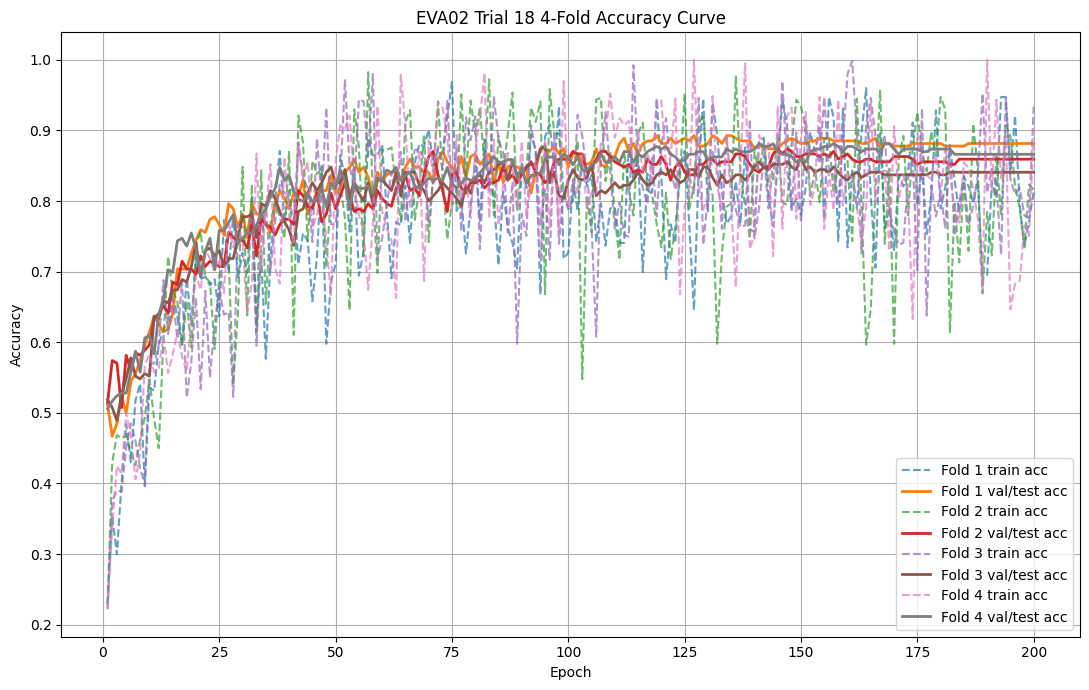

Saved accuracy curve to: /content/drive/MyDrive/Kaggle/eva02_trial18_4fold_200epoch/fullcv_checkpoints/eva02_trial018_4fold_accuracy_curve.png

Found history files:
eva02_trial018_fold1_history.csv
eva02_trial018_fold2_history.csv
eva02_trial018_fold3_history.csv
eva02_trial018_fold4_history.csv

Columns:
['trial_number', 'fold', 'epoch', 'train_loss', 'train_acc', 'val_loss', 'val_acc', 'gap', 'best_acc', 'best_epoch', 'bad_epochs', 'seconds', 'source_file']


,trial_number,fold,epoch,train_loss,train_acc,val_loss,val_acc,gap,best_acc,best_epoch,bad_epochs,seconds,source_file
0,18,1,1,4.589766,0.229323,4.543186,0.511111,-0.281788,0.511111,1,0,174.161736,eva02_trial018_fold1_history.csv
1,18,1,2,4.470369,0.353383,4.328747,0.466667,-0.113283,0.511111,1,1,21.882232,eva02_trial018_fold1_history.csv
2,18,1,3,4.232976,0.299499,3.971181,0.485185,-0.185686,0.511111,1,2,19.695066,eva02_trial018_fold1_history.csv
3,18,1,4,3.851225,0.401003,3.575152,0.522222,-0.121220,0.522222,4,0,20.502246,eva02_trial018_fold1_history.csv
4,18,1,5,3.457963,0.483709,3.176374,0.500000,-0.016291,0.522222,4,1,23.138165,eva02_trial018_fold1_history.csv


epoch_col: epoch
train_acc_col: train_acc
eval_acc_col: val_acc
train_loss_col: train_loss
eval_loss_col: val_loss


,fold,best_epoch,best_val_or_test_acc,final_val_or_test_acc
0,1,119,0.892593,0.881481
1,2,145,0.874074,0.859259
2,3,95,0.877778,0.840741
3,4,141,0.881041,0.866171


Mean best val/test acc: 0.8813713341594382
Mean final val/test acc: 0.8619131212997384
Saved summary to: /content/drive/MyDrive/Kaggle/eva02_trial18_4fold_200epoch/fullcv_checkpoints/eva02_trial018_4fold_accuracy_summary.csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

HIST_DIR = Path("/content/drive/MyDrive/Kaggle/eva02_trial18_4fold_200epoch/fullcv_checkpoints/")

print("Folder exists:", HIST_DIR.exists())
print("Files in folder:")
for f in sorted(HIST_DIR.glob("*")):
    print(f.name)

plt.figure(figsize=(11, 7))

for fold in sorted(hist["fold"].unique()):
    df = hist[hist["fold"] == fold].sort_values(epoch_col)

    if train_acc_col is not None:
        plt.plot(
            df[epoch_col],
            df[train_acc_col],
            linestyle="--",
            alpha=0.7,
            label=f"Fold {fold} train acc"
        )

    plt.plot(
        df[epoch_col],
        df[eval_acc_col],
        linewidth=2,
        label=f"Fold {fold} val/test acc"
    )

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EVA02 Trial 18 4-Fold Accuracy Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()

acc_path = HIST_DIR / "eva02_trial018_4fold_accuracy_curve.png"
plt.savefig(acc_path, dpi=250)
plt.show()

print("Saved accuracy curve to:", acc_path)

history_files = sorted(HIST_DIR.glob("eva02_trial018_fold*_history.csv"))

print("\nFound history files:")
for f in history_files:
    print(f.name)

if len(history_files) == 0:
    raise FileNotFoundError("No eva02_trial018_fold*_history.csv files found in this folder.")

all_hist = []

for f in history_files:
    fold = int(f.name.split("_fold")[1].split("_")[0])
    df = pd.read_csv(f)
    df["fold"] = fold
    df["source_file"] = f.name
    all_hist.append(df)

hist = pd.concat(all_hist, ignore_index=True)

print("\nColumns:")
print(hist.columns.tolist())

display(hist.head())

cols = hist.columns.tolist()

epoch_col = "epoch" if "epoch" in cols else cols[0]

acc_cols = [c for c in cols if "acc" in c.lower()]
loss_cols = [c for c in cols if "loss" in c.lower()]

train_acc_col = next((c for c in acc_cols if "train" in c.lower()), None)
val_acc_col = next((c for c in acc_cols if "val" in c.lower()), None)
test_acc_col = next((c for c in acc_cols if "test" in c.lower()), None)

train_loss_col = next((c for c in loss_cols if "train" in c.lower()), None)
val_loss_col = next((c for c in loss_cols if "val" in c.lower()), None)
test_loss_col = next((c for c in loss_cols if "test" in c.lower()), None)

# Prefer test accuracy if it exists, otherwise use validation accuracy
eval_acc_col = test_acc_col if test_acc_col is not None else val_acc_col
eval_loss_col = test_loss_col if test_loss_col is not None else val_loss_col

print("epoch_col:", epoch_col)
print("train_acc_col:", train_acc_col)
print("eval_acc_col:", eval_acc_col)
print("train_loss_col:", train_loss_col)
print("eval_loss_col:", eval_loss_col)

if eval_acc_col is None:
    raise ValueError("Could not find validation/test accuracy column. Check printed columns above.")

# =========================
# BEST VAL/TEST ACCURACY PER FOLD
# =========================
summary = []

for fold in sorted(hist["fold"].unique()):
    df = hist[hist["fold"] == fold].sort_values(epoch_col).reset_index(drop=True)

    best_idx = df[eval_acc_col].idxmax()
    best_row = df.loc[best_idx]

    summary.append({
        "fold": fold,
        "best_epoch": int(best_row[epoch_col]),
        "best_val_or_test_acc": float(best_row[eval_acc_col]),
        "final_val_or_test_acc": float(df[eval_acc_col].iloc[-1])
    })

summary_df = pd.DataFrame(summary)

display(summary_df)

print("Mean best val/test acc:", summary_df["best_val_or_test_acc"].mean())
print("Mean final val/test acc:", summary_df["final_val_or_test_acc"].mean())

summary_path = HIST_DIR / "eva02_trial018_4fold_accuracy_summary.csv"
summary_df.to_csv(summary_path, index=False)

print("Saved summary to:", summary_path)


Mounted at /content/drive
Folder exists: True
Files in folder:
eva02_trial018_4fold_accuracy_curve.png
eva02_trial018_4fold_accuracy_summary.csv
eva02_trial018_4fold_loss_curve.png
eva02_trial018_fold1_best.pt
eva02_trial018_fold1_history.csv
eva02_trial018_fold2_best.pt
eva02_trial018_fold2_history.csv
eva02_trial018_fold3_best.pt
eva02_trial018_fold3_history.csv
eva02_trial018_fold4_best.pt
eva02_trial018_fold4_history.csv

Found history files:
eva02_trial018_fold1_history.csv
eva02_trial018_fold2_history.csv
eva02_trial018_fold3_history.csv
eva02_trial018_fold4_history.csv

Columns:
['trial_number', 'fold', 'epoch', 'train_loss', 'train_acc', 'val_loss', 'val_acc', 'gap', 'best_acc', 'best_epoch', 'bad_epochs', 'seconds', 'source_file']


,trial_number,fold,epoch,train_loss,train_acc,val_loss,val_acc,gap,best_acc,best_epoch,bad_epochs,seconds,source_file
0,18,1,1,4.589766,0.229323,4.543186,0.511111,-0.281788,0.511111,1,0,174.161736,eva02_trial018_fold1_history.csv
1,18,1,2,4.470369,0.353383,4.328747,0.466667,-0.113283,0.511111,1,1,21.882232,eva02_trial018_fold1_history.csv
2,18,1,3,4.232976,0.299499,3.971181,0.485185,-0.185686,0.511111,1,2,19.695066,eva02_trial018_fold1_history.csv
3,18,1,4,3.851225,0.401003,3.575152,0.522222,-0.121220,0.522222,4,0,20.502246,eva02_trial018_fold1_history.csv
4,18,1,5,3.457963,0.483709,3.176374,0.500000,-0.016291,0.522222,4,1,23.138165,eva02_trial018_fold1_history.csv


epoch_col: epoch
train_loss_col: train_loss
eval_loss_col: val_loss


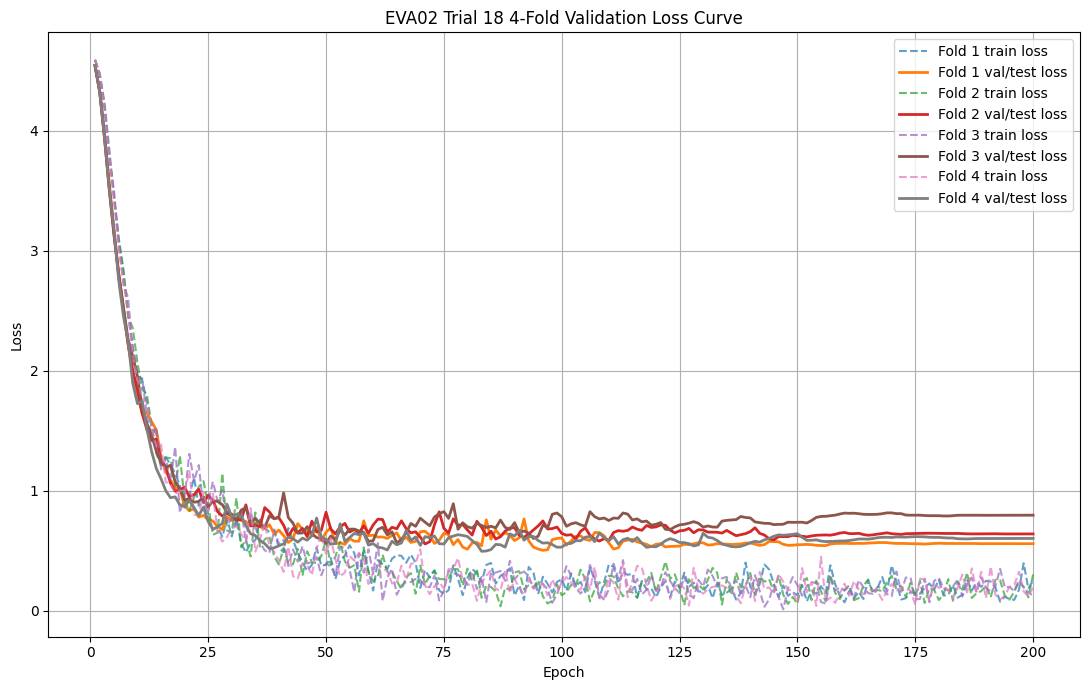

Saved validation loss curve to: /content/drive/MyDrive/Kaggle/eva02_trial18_4fold_200epoch/fullcv_checkpoints/eva02_trial018_4fold_val_loss_curve.png


,fold,best_epoch_by_lowest_val_loss,best_val_or_test_loss,final_val_or_test_loss
0,1,96,0.501704,0.557200
1,2,71,0.554831,0.638472
2,3,50,0.559685,0.794663
3,4,83,0.493398,0.600969


Mean best val/test loss: 0.5274041324531915
Mean final val/test loss: 0.647826147354229
Saved loss summary to: /content/drive/MyDrive/Kaggle/eva02_trial18_4fold_200epoch/fullcv_checkpoints/eva02_trial018_4fold_val_loss_summary.csv


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


HIST_DIR = Path("/content/drive/MyDrive/Kaggle/eva02_trial18_4fold_200epoch/fullcv_checkpoints/")

print("Folder exists:", HIST_DIR.exists())
print("Files in folder:")
for f in sorted(HIST_DIR.glob("*")):
    print(f.name)


history_files = sorted(HIST_DIR.glob("eva02_trial018_fold*_history.csv"))

print("\nFound history files:")
for f in history_files:
    print(f.name)

if len(history_files) == 0:
    raise FileNotFoundError("No eva02_trial018_fold*_history.csv files found in this folder.")


all_hist = []

for f in history_files:
    fold = int(f.name.split("_fold")[1].split("_")[0])
    df = pd.read_csv(f)
    df["fold"] = fold
    df["source_file"] = f.name
    all_hist.append(df)

hist = pd.concat(all_hist, ignore_index=True)

print("\nColumns:")
print(hist.columns.tolist())

display(hist.head())

# =========================
# AUTO-DETECT COLUMNS
# =========================
cols = hist.columns.tolist()

epoch_col = "epoch" if "epoch" in cols else cols[0]

loss_cols = [c for c in cols if "loss" in c.lower()]

train_loss_col = next((c for c in loss_cols if "train" in c.lower()), None)
val_loss_col = next((c for c in loss_cols if "val" in c.lower()), None)
test_loss_col = next((c for c in loss_cols if "test" in c.lower()), None)

# Prefer validation loss if it exists, otherwise test loss
eval_loss_col = val_loss_col if val_loss_col is not None else test_loss_col

print("epoch_col:", epoch_col)
print("train_loss_col:", train_loss_col)
print("eval_loss_col:", eval_loss_col)

if eval_loss_col is None:
    raise ValueError("Could not find validation/test loss column. Check printed columns above.")

# =========================
# VAL LOSS CURVE ONLY
# =========================
plt.figure(figsize=(11, 7))

for fold in sorted(hist["fold"].unique()):
    df = hist[hist["fold"] == fold].sort_values(epoch_col)

    if train_loss_col is not None:
        plt.plot(
            df[epoch_col],
            df[train_loss_col],
            linestyle="--",
            alpha=0.7,
            label=f"Fold {fold} train loss"
        )

    plt.plot(
        df[epoch_col],
        df[eval_loss_col],
        linewidth=2,
        label=f"Fold {fold} val/test loss"
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EVA02 Trial 18 4-Fold Validation Loss Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_path = HIST_DIR / "eva02_trial018_4fold_val_loss_curve.png"
plt.savefig(loss_path, dpi=250)
plt.show()

print("Saved validation loss curve to:", loss_path)

summary = []

for fold in sorted(hist["fold"].unique()):
    df = hist[hist["fold"] == fold].sort_values(epoch_col).reset_index(drop=True)

    best_idx = df[eval_loss_col].idxmin()
    best_row = df.loc[best_idx]

    summary.append({
        "fold": fold,
        "best_epoch_by_lowest_val_loss": int(best_row[epoch_col]),
        "best_val_or_test_loss": float(best_row[eval_loss_col]),
        "final_val_or_test_loss": float(df[eval_loss_col].iloc[-1])
    })

summary_df = pd.DataFrame(summary)

display(summary_df)

print("Mean best val/test loss:", summary_df["best_val_or_test_loss"].mean())
print("Mean final val/test loss:", summary_df["final_val_or_test_loss"].mean())

summary_path = HIST_DIR / "eva02_trial018_4fold_val_loss_summary.csv"
summary_df.to_csv(summary_path, index=False)

print("Saved loss summary to:", summary_path)

# TTA Inference
Validation plus 10-test-time-augmentation prediction using the saved Trial 18 4-fold checkpoints. Run this last.


In [ ]:

#
# Input:
#   /content/drive/MyDrive/Kaggle/train
#   /content/drive/MyDrive/Kaggle/test
#
# Checkpoints:
#   /content/drive/MyDrive/Kaggle/eva02_trial18_4fold_200epoch/fullcv_checkpoints
#
# Output:
#   /content/drive/MyDrive/Kaggle/eva02_trial18_4fold_10tta_ID_target.csv
#   /content/drive/MyDrive/Kaggle/eva02_trial18_4fold_10tta_probs.npy
#   /content/drive/MyDrive/Kaggle/eva02_trial18_4fold_10tta_oof.csv
# ============================================================

!pip -q install timm scikit-learn

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import gc
import glob
import json
import random
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast

import timm
from torchvision import transforms
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass


# ============================================================
# CONFIG
# ============================================================

TRAIN_DIR = "/content/drive/MyDrive/Kaggle/train"
TEST_DIR  = "/content/drive/MyDrive/Kaggle/test"

CKPT_DIR = "/content/drive/MyDrive/Kaggle/eva02_trial18_4fold_200epoch/fullcv_checkpoints"
CKPT_PATTERN = "eva02_trial018_fold*_best.pt"

SAVE_DIR = "/content/drive/MyDrive/Kaggle"

OUT_CSV = os.path.join(SAVE_DIR, "eva02_trial18_4fold_4tta_ID_target.csv")
OUT_PROBS = os.path.join(SAVE_DIR, "eva02_trial18_4fold_4tta_probs.npy")
OOF_CSV = os.path.join(SAVE_DIR, "eva02_trial18_4fold_4tta_oof.csv")
OOF_PROBS = os.path.join(SAVE_DIR, "eva02_trial18_4fold_4tta_oof_probs.npy")
SUMMARY_JSON = os.path.join(SAVE_DIR, "eva02_trial18_4fold_4tta_summary.json")

SEED = 42
NUM_CLASSES = 100
N_FOLDS = 4

IMG_SIZE = 448
TTA_N = 4

# L4 safe values
BATCH_SIZE = 100
NUM_WORKERS = 8

USE_AMP = True

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM GB:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True


# ============================================================
# SEED
# ============================================================

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)


# ============================================================
# MODEL NAME RESOLUTION
# ============================================================

def resolve_model_name(patterns):
    all_models = set(timm.list_models(pretrained=True))
    for p in patterns:
        matches = sorted([m for m in all_models if p in m])
        if matches:
            print("Resolved", p, "->", matches[0])
            return matches[0]
    raise ValueError(f"No timm model found for patterns: {patterns}")

MODEL_NAME = resolve_model_name([
    "eva02_large_patch14_448.mim_m38m_ft_in22k_ft_in1k",
    "eva02_large_patch14_448",
    "eva02_large",
])


# ============================================================
# DATA HELPERS
# ============================================================

def get_train_items(train_dir):
    items = []

    labels = sorted(
        [x for x in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, x))],
        key=lambda x: int(x) if x.isdigit() else x
    )

    for label in labels:
        class_dir = os.path.join(train_dir, label)
        for fname in os.listdir(class_dir):
            if fname.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
                items.append((os.path.join(class_dir, fname), int(label)))

    return items


def get_test_items(test_dir):
    files = []

    for fname in os.listdir(test_dir):
        if fname.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
            files.append(fname)

    files = sorted(
        files,
        key=lambda x: int(os.path.splitext(x)[0]) if os.path.splitext(x)[0].isdigit() else x
    )

    return [(os.path.join(test_dir, f), f) for f in files]


class ImageDataset(Dataset):
    def __init__(self, items, transform=None):
        self.items = items
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, label_or_id = self.items[idx]

        img = Image.open(path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label_or_id


# ============================================================
# TRANSFORMS
# ============================================================

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

val_tfms = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.10)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Random 4-TTA transform
tta_tfms = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.12)),
    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.88, 1.00),
        ratio=(0.96, 1.04),
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.04,
        contrast=0.04,
        saturation=0.04,
        hue=0.01,
    ),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


# ============================================================
# CHECKPOINT LOADING
# ============================================================

def clean_state_dict(ckpt):
    if isinstance(ckpt, dict):
        if "model_state_dict" in ckpt:
            state = ckpt["model_state_dict"]
        elif "model" in ckpt and isinstance(ckpt["model"], dict):
            state = ckpt["model"]
        elif "state_dict" in ckpt and isinstance(ckpt["state_dict"], dict):
            state = ckpt["state_dict"]
        else:
            state = ckpt
    else:
        state = ckpt

    new_state = {}

    for k, v in state.items():
        k = k.replace("module.", "")
        k = k.replace("model.", "")
        new_state[k] = v

    return new_state


def build_model_from_ckpt(ckpt):
    params = ckpt.get("params", {})

    model = timm.create_model(
        MODEL_NAME,
        pretrained=False,
        num_classes=NUM_CLASSES,
        drop_rate=params.get("drop_rate", 0.0),
        drop_path_rate=params.get("drop_path_rate", 0.0),
    )

    return model


def load_model_from_ckpt(ckpt_path):
    print("\nLoading:", ckpt_path)

    ckpt = torch.load(ckpt_path, map_location="cpu")

    model = build_model_from_ckpt(ckpt)

    state = clean_state_dict(ckpt)
    missing, unexpected = model.load_state_dict(state, strict=False)

    print("Missing keys:", len(missing), "| Unexpected keys:", len(unexpected))

    if len(missing) > 0:
        print("Missing examples:", missing[:5])
    if len(unexpected) > 0:
        print("Unexpected examples:", unexpected[:5])

    model.to(DEVICE)
    model.eval()

    return model, ckpt


def cleanup():
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()


# ============================================================
# PREDICT WITH TTA
# ============================================================

@torch.no_grad()
def predict_items_tta(model, items, tta_n=10, batch_size=8):
    """
    Returns:
        probs: shape [N, NUM_CLASSES]
        ids_or_labels: labels or test IDs
    """

    final_probs = None
    final_ids = None

    for tta_i in range(tta_n):
        ds = ImageDataset(items, transform=tta_tfms)

        loader = DataLoader(
            ds,
            batch_size=batch_size,
            shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=True if DEVICE == "cuda" else False,
            persistent_workers=False,
        )

        probs_list = []
        ids_list = []

        pbar = tqdm(loader, desc=f"TTA {tta_i + 1}/{tta_n}", leave=False)

        for x, ids in pbar:
            x = x.to(DEVICE, non_blocking=True)

            with autocast(device_type="cuda", enabled=(USE_AMP and DEVICE == "cuda")):
                logits = model(x)

            probs = torch.softmax(logits, dim=1).float().cpu().numpy()

            probs_list.append(probs)

            if torch.is_tensor(ids):
                ids = ids.cpu().numpy().tolist()
            else:
                ids = list(ids)

            ids_list.extend(ids)

        probs_this = np.concatenate(probs_list, axis=0)

        if final_probs is None:
            final_probs = probs_this
            final_ids = ids_list
        else:
            final_probs += probs_this
            assert final_ids == ids_list, "Order mismatch during TTA."

        del ds, loader, probs_list
        cleanup()

    final_probs /= tta_n

    return final_probs, final_ids


# ============================================================
# MAIN
# ============================================================

print("\nChecking paths...")
print("Train exists:", os.path.exists(TRAIN_DIR), TRAIN_DIR)
print("Test exists:", os.path.exists(TEST_DIR), TEST_DIR)
print("Checkpoint dir exists:", os.path.exists(CKPT_DIR), CKPT_DIR)

train_items = get_train_items(TRAIN_DIR)
test_items = get_test_items(TEST_DIR)

labels = np.array([y for _, y in train_items])

print("\nDataset:")
print("Train images:", len(train_items))
print("Test images:", len(test_items))
print("Classes:", len(set(labels)))
print("Smallest class:", pd.Series(labels).value_counts().min())
print("Largest class:", pd.Series(labels).value_counts().max())

assert len(train_items) > 0, "No training images found."
assert len(test_items) > 0, "No test images found."
assert len(set(labels)) == NUM_CLASSES, f"Expected {NUM_CLASSES} classes."

ckpts = sorted(glob.glob(os.path.join(CKPT_DIR, CKPT_PATTERN)))

print("\nFound checkpoints:")
for c in ckpts:
    print(" ", c)

assert len(ckpts) > 0, f"No checkpoints found in {CKPT_DIR}"
assert len(ckpts) >= N_FOLDS, f"Expected at least {N_FOLDS} checkpoints, found {len(ckpts)}"

ckpts = ckpts[:N_FOLDS]


# ============================================================
# 4-FOLD VALIDATION WITH 10 TTA
# ============================================================

skf = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=SEED,
)

oof_probs = np.zeros((len(train_items), NUM_CLASSES), dtype=np.float32)
oof_preds = np.zeros(len(train_items), dtype=np.int64)

fold_results = []

for fold_idx, (train_idx, val_idx) in enumerate(
    skf.split(np.zeros(len(labels)), labels),
    start=1
):
    print("\n" + "=" * 90)
    print(f"FOLD {fold_idx}/{N_FOLDS} VALIDATION WITH {TTA_N} TTA")
    print("=" * 90)

    ckpt_path = ckpts[fold_idx - 1]

    model, ckpt = load_model_from_ckpt(ckpt_path)

    val_items = [train_items[i] for i in val_idx]
    val_true = labels[val_idx]

    val_probs, val_ids = predict_items_tta(
        model=model,
        items=val_items,
        tta_n=TTA_N,
        batch_size=BATCH_SIZE,
    )

    val_pred = val_probs.argmax(axis=1)
    val_acc = accuracy_score(val_true, val_pred)

    print(f"Fold {fold_idx} 10-TTA Acc: {val_acc:.5f}")

    oof_probs[val_idx] = val_probs
    oof_preds[val_idx] = val_pred

    fold_results.append({
        "fold": fold_idx,
        "ckpt": ckpt_path,
        "tta_acc": float(val_acc),
        "ckpt_best_acc": float(ckpt.get("best_acc", -1)),
        "ckpt_epoch": int(ckpt.get("epoch", -1)),
    })

    del model, ckpt
    cleanup()


overall_oof_acc = accuracy_score(labels, oof_preds)

print("\n" + "=" * 90)
print("OOF RESULTS")
print("=" * 90)

for fr in fold_results:
    print(
        f"Fold {fr['fold']} | 10-TTA Acc {fr['tta_acc']:.5f} | "
        f"Original CKPT Best {fr['ckpt_best_acc']:.5f} @ Epoch {fr['ckpt_epoch']}"
    )

print(f"\nMean fold 10-TTA acc: {np.mean([fr['tta_acc'] for fr in fold_results]):.5f}")
print(f"Std fold 10-TTA acc:  {np.std([fr['tta_acc'] for fr in fold_results]):.5f}")
print(f"OOF 10-TTA acc:       {overall_oof_acc:.5f}")


# Save OOF
oof_df = pd.DataFrame({
    "path": [x[0] for x in train_items],
    "true_label": labels,
    "pred_label": oof_preds,
    "correct": labels == oof_preds,
})

oof_df.to_csv(OOF_CSV, index=False)
np.save(OOF_PROBS, oof_probs)

print("\nSaved OOF CSV:", OOF_CSV)
print("Saved OOF probs:", OOF_PROBS)


# ============================================================
# TEST PREDICTION WITH 4 FOLDS x 10 TTA
# ============================================================

print("\n" + "=" * 90)
print(f"TEST PREDICTION: {N_FOLDS} FOLDS x {TTA_N} TTA")
print("=" * 90)

test_probs_sum = np.zeros((len(test_items), NUM_CLASSES), dtype=np.float32)
test_ids_final = None

for fold_idx, ckpt_path in enumerate(ckpts, start=1):
    print("\n" + "-" * 90)
    print(f"Predicting test with fold {fold_idx}/{N_FOLDS}")
    print("-" * 90)

    model, ckpt = load_model_from_ckpt(ckpt_path)

    test_probs, test_ids = predict_items_tta(
        model=model,
        items=test_items,
        tta_n=TTA_N,
        batch_size=BATCH_SIZE,
    )

    if test_ids_final is None:
        test_ids_final = test_ids
    else:
        assert test_ids_final == test_ids, "Test ID order mismatch."

    test_probs_sum += test_probs.astype(np.float32)

    del model, ckpt
    cleanup()

test_probs_avg = test_probs_sum / N_FOLDS
test_probs_avg = np.clip(test_probs_avg, 0, None)
test_probs_avg = test_probs_avg / test_probs_avg.sum(axis=1, keepdims=True)

test_preds = test_probs_avg.argmax(axis=1).astype(int)


# ============================================================
# SAVE SUBMISSION
# ============================================================

submission = pd.DataFrame({
    "ID": test_ids_final,
    "target": test_preds,
})

submission.to_csv(OUT_CSV, index=False)
np.save(OUT_PROBS, test_probs_avg)

summary = {
    "model_name": MODEL_NAME,
    "img_size": IMG_SIZE,
    "n_folds": N_FOLDS,
    "tta_n": TTA_N,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "oof_10tta_acc": float(overall_oof_acc),
    "mean_fold_10tta_acc": float(np.mean([fr["tta_acc"] for fr in fold_results])),
    "std_fold_10tta_acc": float(np.std([fr["tta_acc"] for fr in fold_results])),
    "fold_results": fold_results,
    "out_csv": OUT_CSV,
    "out_probs": OUT_PROBS,
    "oof_csv": OOF_CSV,
    "oof_probs": OOF_PROBS,
}

with open(SUMMARY_JSON, "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "=" * 90)
print("DONE")
print("=" * 90)

print("Saved submission:", OUT_CSV)
print("Saved test probs:", OUT_PROBS)
print("Saved OOF CSV:", OOF_CSV)
print("Saved OOF probs:", OOF_PROBS)
print("Saved summary:", SUMMARY_JSON)

print("\nSubmission preview:")
print(submission.head())

print("\nSubmission shape:", submission.shape)

print("\nClass count preview:")
print(submission["target"].value_counts().sort_index().head(30))

Mounted at /content/drive
Device: cuda
GPU: NVIDIA L4
VRAM GB: 22.03
Resolved eva02_large_patch14_448 -> eva02_large_patch14_448.mim_in22k_ft_in1k

Checking paths...
Train exists: True /content/drive/MyDrive/Kaggle/train
Test exists: True /content/drive/MyDrive/Kaggle/test
Checkpoint dir exists: True /content/drive/MyDrive/Kaggle/eva02_trial18_4fold_200epoch/fullcv_checkpoints

Dataset:
Train images: 1079
Test images: 1036
Classes: 100
Smallest class: 4
Largest class: 41

Found checkpoints:
  /content/drive/MyDrive/Kaggle/eva02_trial18_4fold_200epoch/fullcv_checkpoints/eva02_trial018_fold1_best.pt
  /content/drive/MyDrive/Kaggle/eva02_trial18_4fold_200epoch/fullcv_checkpoints/eva02_trial018_fold2_best.pt
  /content/drive/MyDrive/Kaggle/eva02_trial18_4fold_200epoch/fullcv_checkpoints/eva02_trial018_fold3_best.pt
  /content/drive/MyDrive/Kaggle/eva02_trial18_4fold_200epoch/fullcv_checkpoints/eva02_trial018_fold4_best.pt

FOLD 1/4 VALIDATION WITH 4 TTA

Loading: /content/drive/MyDrive/Kag

TTA 1/4:   0%|          | 0/3 [00:00<?, ?it/s]

TTA 2/4:   0%|          | 0/3 [00:00<?, ?it/s]

Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 178, in close
Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 178, in close
    reader_close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    self._cl

TTA 3/4:   0%|          | 0/3 [00:00<?, ?it/s]

...

TTA 1/4:   0%|          | 0/11 [00:00<?, ?it/s]

TTA 2/4:   0%|          | 0/11 [00:00<?, ?it/s]

TTA 3/4:   0%|          | 0/11 [00:00<?, ?it/s]

TTA 4/4:   0%|          | 0/11 [00:00<?, ?it/s]


DONE
Saved submission: /content/drive/MyDrive/Kaggle/eva02_trial18_4fold_4tta_ID_target.csv
Saved test probs: /content/drive/MyDrive/Kaggle/eva02_trial18_4fold_4tta_probs.npy
Saved OOF CSV: /content/drive/MyDrive/Kaggle/eva02_trial18_4fold_4tta_oof.csv
Saved OOF probs: /content/drive/MyDrive/Kaggle/eva02_trial18_4fold_4tta_oof_probs.npy
Saved summary: /content/drive/MyDrive/Kaggle/eva02_trial18_4fold_4tta_summary.json

Submission preview:
      ID  target
0  0.jpg      62
1  1.jpg      43
2  2.jpg      38
3  3.jpg      51
4  4.jpg      42

Submission shape: (1036, 2)

Class count preview:
target
0      6
1      9
2     11
3      9
4     10
5     11
6     12
7     10
8     10
9     10
10    11
11     9
12    11
13     6
14     9
15    12
16     8
17    10
18    11
19    12
20    13
21    11
22     9
23    10
24    10
25    12
26    10
27     8
28    12
29    10
Name: count, dtype: int64
